<a id="toc"></a>
<p><center style="color:green; font-family: 'Pacifico', cursive; font-size:25px;">Thanks for visiting my notebook </center></p>

<div style="background-color:white; padding: 2px;">
<div class="alert alert-block alert-secondary" style="font-size:35px; font-family:'Merriweather'; text-align:center">  🏠💰House Pricing EDA and Extensive Modeling📊🤖</div></div>

<div>

 <h1 align="left"><font color=red>About the Notebook</font></h1>

I created this notebook recently under '**Price Prophet**', an end-to-end MLOps pipeline for House Price Prediction.

Feel free to learn from the notebook as per your needs. If you find it nice exploring, please `upvote` it so that it can reach others and also I get motivated to build more interesting notebooks.

<div>

 <h1 align="left"><font color=red>Table of Contents</font></h1></div>
 
<a id="toc"></a>
- [ 1 - Import Libraries ](#1)
- [ 2 - Data Loading](#2)
- [ 3 - Dataset Overview](#3)
- [ 4 - EDA](#4)
  - [ 4.1 Basic Data Inspection](#4.1)
  - [ 4.2 Insights-I](#4.2)
  - [ 4.3 Univariate Analysis](#4.3)
  - [ 4.4 Bivariate Analysis](#4.4)
  - [ 4.5 Insights-II](#4.5)
  - [ 4.6 Multivariate Analysis](#4.6)
  - [ 4.7 Insights-III](#4.7)
  - [ 4.8 Missing Value Analysis](#4.8)
  - [ 4.9 Insights-IV](#4.9) 
- [ 5 - Modeling](#5)
  - [ 5.1 Pipeline-I (Basic)](#5.1)
    - [5.1.1 Linear Regression](#5.1.1)
    - [5.1.2 Lasso](#5.1.2)
    - [5.1.3 Elastic Net](#5.1.3)
    - [5.1.4 Kernel Ridge](#5.1.4)
    - [5.1.5 Gradient Boosting Regressor](#5.1.5)
    - [5.1.6 Extreme Boost](#5.1.6)
    - [5.1.7 Light Gradient Boost](#5.1.7)
    - [5.1.8 Average Ensemble-1](#5.1.8)
    - [5.1.9 Average Ensemble-2](#5.1.9)
    - [5.1.10 Stacking Ensemble](#5.1.10)
    - [5.1.11 Comparative Model Evaluation Metrics](#5.1.11)
  - [ 5.2 Pipeline-II (Slight Modified)](#5.2)
    - [5.2.1 Comparative Model Evaluation Metrics](#5.2.1)
  - [ 5.3 Pipeline-III (Step by step - Different approach)](#5.3)
    - [5.3.1 Outliers and Target Variable](#5.2.1)
    - [5.3.2 Handling Missing Values](#5.2.1)
    - [5.3.3 More Feature Engineering](#5.2.1)
    - [5.3.4 Feature Type Transform](#5.2.1)
    - [5.3.5 Label Encoding](#5.2.1)
    - [5.3.6 Detecting Skewed Features](#5.2.1)
    - [5.3.7 Assemble](#5.2.1)
  - [ 5.4 Pipeline-IV (Heavy Feature Engineering)](#5.4)
    - [5.4.1 Using Linear Regression](#5.4.1)
    - [5.4.2 Using XGBoost Regressor](#5.4.2)
    - [5.4.3 Using LightGBM Regressor](#5.4.3)
    - [5.4.4 Using Averaged Model (LGBM+XGB)](#5.4.4)
    - [5.4.5 Using CatBoost Regressor](#5.4.5)
    - [5.4.6 Hyperparameter Tuning](#5.4.6)
    - [5.4.7 Best Model](#5.4.7)

<a id="toc"></a>

<a href="#toc" style="background-color: red; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="1"></a>
# <b><span style='color:red'>Import Libraries</span></b> 

In [1]:
# ========== General Utilities ==========
import warnings
import numpy as np
import pandas as pd
from typing import List, Tuple, Union

# ========== Visualization ==========
import matplotlib.pyplot as plt
import seaborn as sns

# Enable inline plotting
%matplotlib inline
sns.set_style('darkgrid')
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))

# ========== Statistical Tools ==========
from scipy import stats
from scipy.stats import norm, skew
from scipy.special import boxcox1p

# ========== Preprocessing ==========
from sklearn.preprocessing import (
    RobustScaler, MinMaxScaler, StandardScaler, OneHotEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from category_encoders.cat_boost import CatBoostEncoder

# ========== Models ==========
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, StackingRegressor
from sklearn.kernel_ridge import KernelRidge

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

# ========== Pipeline Tools ==========
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone

# ========== Evaluation ==========
from sklearn.metrics import mean_squared_error, r2_score

# ========== Warnings ==========
warnings.filterwarnings('ignore')

<a id="toc"></a>

<a href="#toc" style="background-color: red; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="2"></a>
# <b><span style='color:red'>Load Data ~ Ames Housing Dataset</span></b>

In [2]:
df = pd.read_csv('/kaggle/input/ames-housing-dataset/AmesHousing.csv')
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.000,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.000,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.000,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.000,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.000,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


<a id="toc"></a>

<a href="#toc" style="background-color: red; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="3"></a>
# <b><span style='color:red'>Dataset Overview</span></b>

The Ames Housing dataset contains detailed information on 2,930 residential homes in Ames, Iowa, covering 80 explanatory variables that describe various aspects of residential homes.

It serves as an advanced replacement for the Boston Housing dataset and includes features such as:

- Lot size, year built, neighborhood, and number of bathrooms
- Qualitative and quantitative attributes
- A mix of numerical, ordinal, and categorical features

📌 **Target Variable**: `SalePrice` – the final price of each house.

**Original Source**: [House Prices - ART Competition](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)


<a id="toc"></a>

<a href="#toc" style="background-color: red; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="4"></a>
# <b><span style='color:red'>EDA</span></b>

*Before diving into modeling, it's essential to understand the structure and content of the dataset.* 

In this section, we'll explore the dataset using the following steps:

1. 📌 **Basic Data Inspection** – column types, sample rows, and summary stats.
2. 📊 **Univariate Analysis** – Individual feature distributions and statistics.
3. 🔁 **Bivariate Analysis** – Feature vs. target relationships and correlations.
4. 🔗 **Multivariate Analysis** – Interactions between multiple variables.
5. ❓ **Missing Value Analysis** – Identifying and understanding missing data.

This systematic approach ensures we uncover useful patterns, detect anomalies, and identify necessary preprocessing steps.

But before that let's begin our exploratory data analysis by examining:

- Dataset shape (rows × columns)
- Available features (column names)

This helps us grasp the overall data structure and dimensionality.*

In [3]:
# Basic dataset info
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

Dataset Shape: 2930 rows × 82 columns



In [4]:
# Preview column names
print("Columns:")
print(list(df.columns))

Columns:
['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'W

<a href="#toc" style="background-color:red; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="4.1"></a>
## <b><span style='color:red'>Basic Data Inspection</span></b>

**Data Types and Non-null counts of dataframe columns**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

**Summary Statistics for Numerical Features**

In [6]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.000,2930.000,2930.000,2440.000,2930.000,2930.000,2930.000,2930.000,2930.000,2907.000,...,2930.000,2930.000,2930.000,2930.000,2930.000,2930.000,2930.000,2930.000,2930.000,2930.000
mean,1465.500,714464496.989,57.387,69.225,10147.922,6.095,5.563,1971.356,1984.267,101.897,...,93.752,47.533,23.012,2.592,16.002,2.243,50.635,6.216,2007.790,180796.060
std,845.962,188730844.649,42.638,23.365,7880.018,1.411,1.112,30.245,20.860,179.113,...,126.362,67.483,64.139,25.141,56.087,35.597,566.344,2.714,1.317,79886.692
min,1.000,526301100.000,20.000,21.000,1300.000,1.000,1.000,1872.000,1950.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,2006.000,12789.000
25%,733.250,528477022.500,20.000,58.000,7440.250,5.000,5.000,1954.000,1965.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,4.000,2007.000,129500.000
50%,1465.500,535453620.000,50.000,68.000,9436.500,6.000,5.000,1973.000,1993.000,0.000,...,0.000,27.000,0.000,0.000,0.000,0.000,0.000,6.000,2008.000,160000.000
75%,2197.750,907181097.500,70.000,80.000,11555.250,7.000,6.000,2001.000,2004.000,164.000,...,168.000,70.000,0.000,0.000,0.000,0.000,0.000,8.000,2009.000,213500.000
max,2930.000,1007100110.000,190.000,313.000,215245.000,10.000,9.000,2010.000,2010.000,1600.000,...,1424.000,742.000,1012.000,508.000,576.000,800.000,17000.000,12.000,2010.000,755000.000


In [7]:
# For specific column 'SalePrice', summary stats are as follows:
df['SalePrice'].describe()

count     2930.000
mean    180796.060
std      79886.692
min      12789.000
25%     129500.000
50%     160000.000
75%     213500.000
max     755000.000
Name: SalePrice, dtype: float64

**Summary Statistics for Categorical Features**

In [8]:
df.describe(include = 'object')

,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
count,2930,2930,198,2930,2930,2930,2930,2930,2930,2930,...,2773,2771,2771,2771,2930,13,572,106,2930,2930
unique,7,2,2,4,4,3,5,3,28,9,...,6,3,5,5,3,4,4,5,10,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,2273,2918,120,1859,2633,2927,2140,2789,443,2522,...,1731,1231,2615,2665,2652,4,330,95,2536,2413


In [9]:
# For specific column 'Neighborhood', summary stats are as follows:
df['Neighborhood'].describe()

count      2930
unique       28
top       NAmes
freq        443
Name: Neighborhood, dtype: object

<a href="#toc" style="background-color:red; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="4.2"></a>
## <b><span style='color:red'>Insights-I</span></b>

#### **1. Data Types and Non-null Counts:**
- The dataset contains **2930 entries** and **82 columns**.
- **Data Types**: There are 11 columns with `float64` data type, 28 columns with `int64` data type, and 43 columns with `object` data type.
  - **Numerical Features**: These include features like `Lot Frontage`, `Lot Area`, `Overall Qual`, `Year Built`, etc.
  - **Categorical Features**: Features like `MS Zoning`, `Street`, `Neighborhood`, `Bldg Type`, etc., are categorical.

#### **2. Summary Statistics:**
- **Numerical Features**:
  - The target variable `SalePrice` has a mean of **180,796** dollars, with a standard deviation of **$79,886**, indicating a significant spread in house prices.
  - `Overall Qual` (quality of the house) ranges from **1 to 10**, with a mean of **6.09**, showing a relatively high quality on average.
  - `Year Built` ranges from **1872 to 2010**, indicating that the dataset includes both very old and relatively new houses.
  - `Lot Area` has a wide range, with some extreme outliers (maximum of **215,245 sq ft**), which might indicate large properties.
  - The distribution of `Gr Liv Area` (above ground living area) shows a mean of **1499 sq ft** with a wide range, which could significantly impact `SalePrice`.

- **Categorical Features**:
  - **Neighborhood** has **28 unique values**, with `NAmes` being the most common, suggesting some neighborhoods might dominate the dataset.
  - **MS Zoning** is mostly `RL` (residential low-density), with **7 unique zoning types**.
  - `Alley` has a high frequency of missing values (discussed below).
  - Several features related to basements, garages, and exterior quality vary significantly, which will be crucial in predicting `SalePrice`.


<a href="#toc" style="background-color:red; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="4.3"></a>
## <b><span style='color:red'>Univariate Analysis</span></b>

### Numerical Variate Analysis

In [10]:
# For nice visualization of any numerical feature
def nva(df: pd.DataFrame, feature: str):
    plt.figure(figsize=(10, 6))
    # Histogram plot of the numerical feature
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

***Analyzing SalePrice***

<Axes: xlabel='SalePrice', ylabel='Density'>

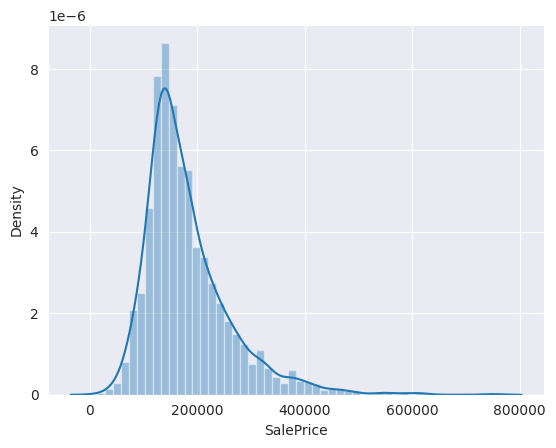

In [11]:
# Analyzing univariate distribution for target numerical faeture
sns.distplot(df['SalePrice'])

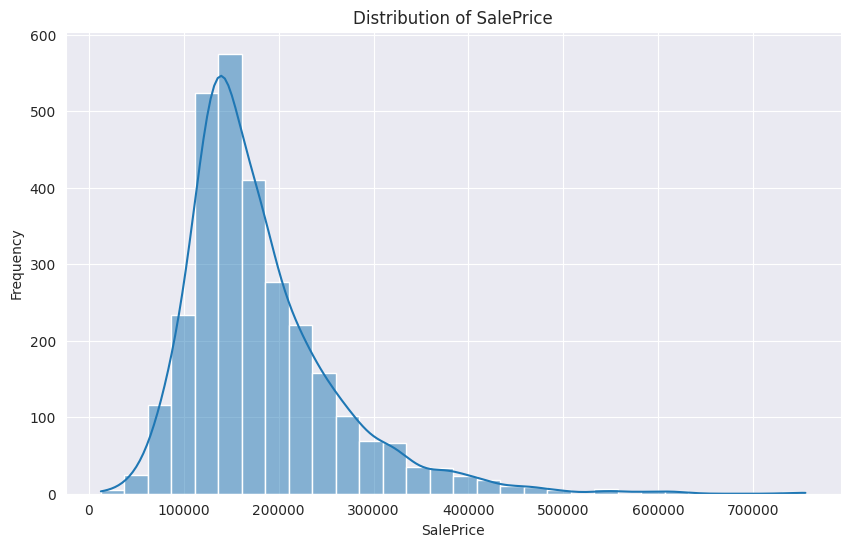

In [12]:
nva(df,'SalePrice')

*We can infer that `SalePrice`*
- Deviates from the normal distribution.
- Has appreciable positive skewness.
- Shows peakedness.

In [13]:
#skewness and kurtosis
print("Skewness: %f" % df['SalePrice'].skew())
print("Kurtosis: %f" % df['SalePrice'].kurt())

Skewness: 1.743500
Kurtosis: 5.118900


### Categorical Variate Analysis

In [14]:
def cva(df: pd.DataFrame, feature: str):
    plt.figure(figsize=(10, 6))
    sns.countplot(x=feature, data=df, palette="muted")
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

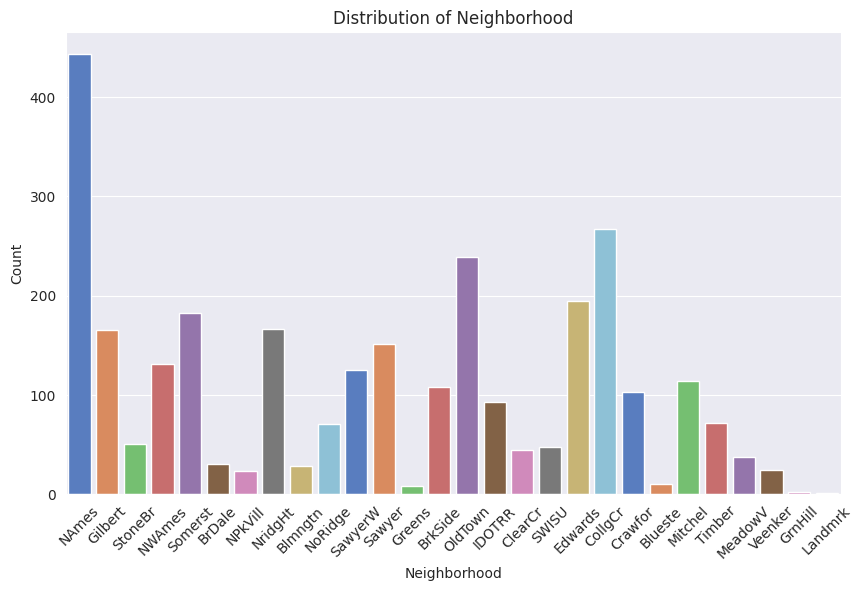

In [15]:
cva(df,'Neighborhood')

<a href="#toc" style="background-color:red; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="4.4"></a>
## <b><span style='color:red'>Bivariate Analysis</span></b>

**Numerical vs Numerical Analysis**

In [16]:
def nvn(df: pd.DataFrame, feature1: str, feature2: str):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=feature1, y=feature2, data=df)
    plt.title(f"{feature1} vs {feature2}")
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.show()

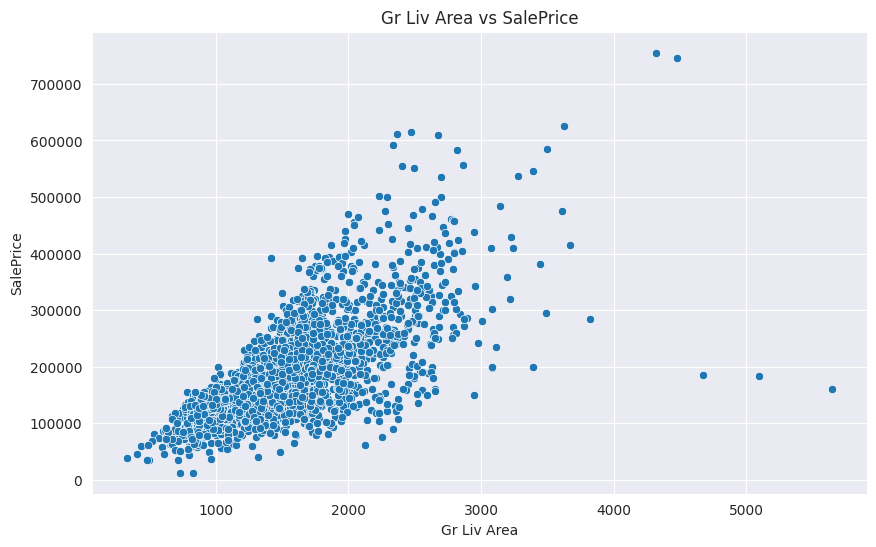

In [17]:
nvn(df, 'Gr Liv Area', 'SalePrice')

*It seems that `SalePrice` and `GrLivArea` are really old friends, with a linear relationship.*

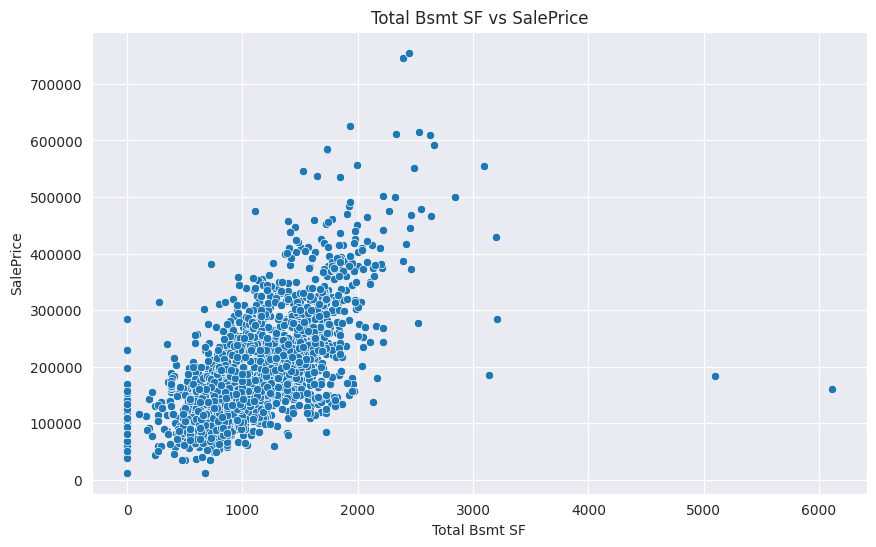

In [18]:
nvn(df, 'Total Bsmt SF', 'SalePrice')

*`TotalBsmtSF` is also a great friend of `SalePrice`.*

**Categorical vs Numerical Analysis**

In [19]:
def cvn(df: pd.DataFrame, feature1: str, feature2: str):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=feature1, y=feature2, data=df)
    plt.title(f"{feature1} vs {feature2}")
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.xticks(rotation=45)
    plt.show()

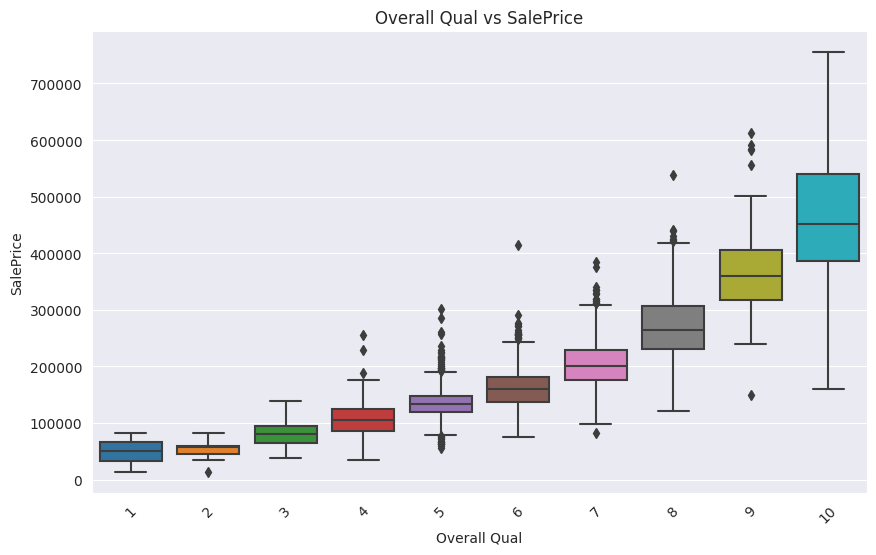

In [20]:
cvn(df, 'Overall Qual', 'SalePrice')

*`SalePrice` enjoys company of `OverallQual`.*

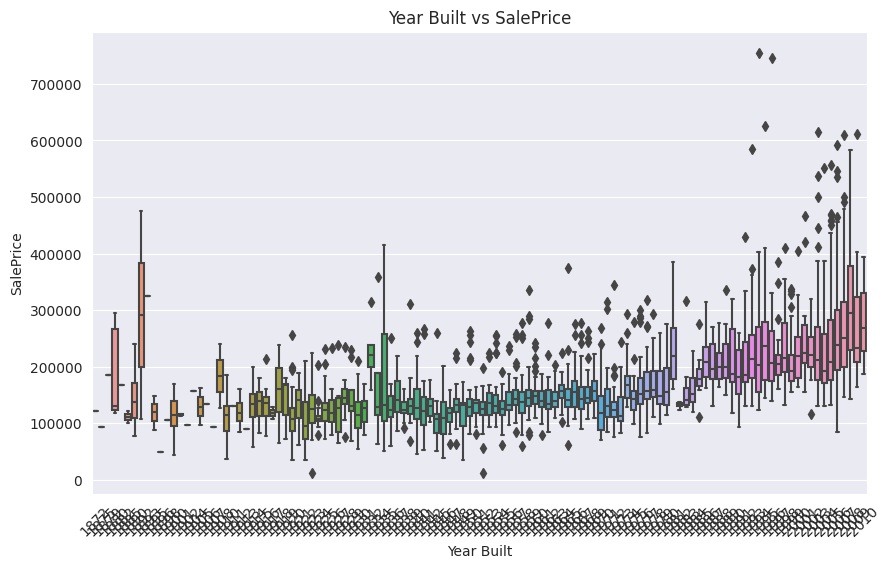

In [21]:
cvn(df, 'Year Built', 'SalePrice')

<a href="#toc" style="background-color:red; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="4.5"></a>
## <b><span style='color:red'>Insights-II</span></b>

#### **3. Univariate Analysis**

1. **SalePrice Distribution (Numerical Feature)**:
   - **Insight**: The distribution of `SalePrice` is positively skewed, with the majority of house prices falling between 100,000 and 250,000. The peak frequency is around the $200,000 mark.
   - **Implication**: This skewness suggests that most homes in the dataset are relatively affordable, with fewer high-end properties. The long tail on the right side indicates a small number of more expensive homes, which may need special consideration during modeling (e.g., applying a log transformation to normalize the distribution).

2. **Neighborhood Distribution (Categorical Feature)**:
   - **Insight**: The `Neighborhood` feature shows a varied distribution, with `NAmes` being the most common neighborhood, followed by `CollgCr` and `OldTown`. Some neighborhoods have very few observations.
   - **Implication**: The high frequency of certain neighborhoods suggests that these areas could significantly influence overall housing prices. Neighborhoods with fewer observations might require careful handling to avoid overfitting during model training, potentially using techniques like frequency encoding or grouping similar neighborhoods together.

#### **4. Bivariate Analysis**

1. **Gr Liv Area vs. SalePrice (Numerical vs. Numerical)**:
   - **Insight**: There is a strong positive correlation between `Gr Liv Area` (Above Ground Living Area) and `SalePrice`, indicating that larger homes generally sell for higher prices. The relationship appears mostly linear, but there are a few outliers, especially at higher `Gr Liv Area` values.
   - **Implication**: This linear relationship confirms that `Gr Liv Area` is likely a strong predictor of `SalePrice`. However, the presence of outliers (large homes with lower than expected prices) might require further investigation to determine whether they should be treated or removed.

2. **Overall Qual vs. SalePrice (Categorical vs. Numerical)**:
   - **Insight**: There is a clear positive relationship between `Overall Qual` (Overall Quality) and `SalePrice`, with higher quality ratings associated with significantly higher prices. The box plot shows increasing medians and ranges as quality improves, with some variability in each category.
   - **Implication**: `Overall Qual` is another strong predictor of `SalePrice`. The consistent increase in sale price with higher quality ratings suggests that homebuyers highly value quality. The variability within each category might be due to other factors influencing price, such as location or specific features not captured by `Overall Qual`.

### **Summary**:
- **Key Predictors**: 
  - `Gr Liv Area` and `Total Bsmt SF` seem to be linearly related with `SalePrice`. Both relationships are positive, which means that as one variable increases, the other also increases. In the case of `Total Bsmt SF`, we can see that the slope of the linear relationship is particularly high.
  - `Overall Qual` and `Year Built` also seem to be related with `SalePrice`. The relationship seems to be stronger in the case of `Overall Qual`, where the box plot shows how sales prices increase with the overall quality.

- **Data Distribution**: The positive skew in `SalePrice` and the wide range of values for both `Gr Liv Area` and `Overall Qual` indicate the need for careful data preprocessing, including potential normalization or transformation of features.
- **Outliers**: Outliers in the relationship between `Gr Liv Area` and `SalePrice` need to be examined closely, as they may represent special cases (e.g., luxury homes) that could skew the model if not properly addressed.

<a href="#toc" style="background-color:red; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="4.6"></a>
## <b><span style='color:red'>Multivariate Analysis</span></b>

### Correlation Heatmap

<Axes: >

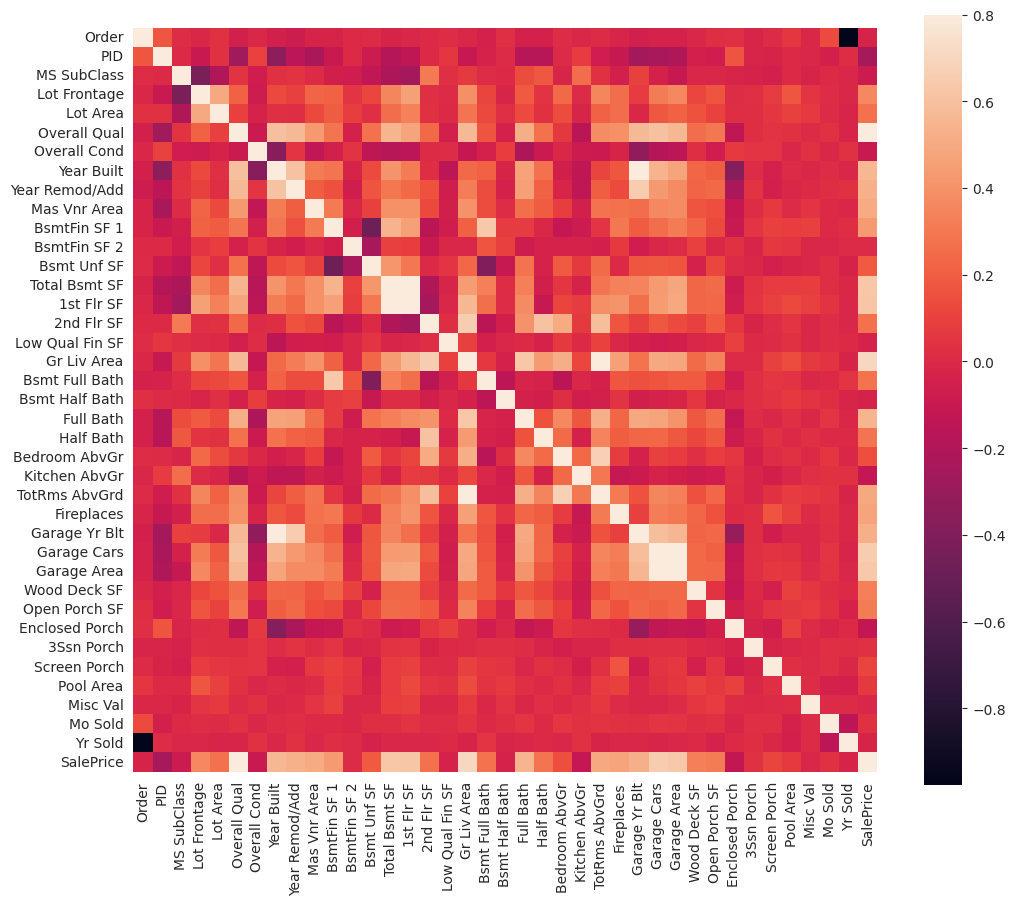

In [22]:
# correlation matrix for numerical features of dataframe
corrmat = df.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corrmat, vmax=.8, square=True)

Here, **red** cells show **negative correlation** and **white** cells show **positive correlation**

In [23]:
def generate_ch(df: pd.DataFrame):
    plt.figure(figsize=(12, 10))
    sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
    plt.title("Correlation Heatmap")
    plt.show()

In [24]:
# Selecting important features for the analysis
cols = ['SalePrice', 'Gr Liv Area', 'Overall Qual', 'Total Bsmt SF', 'Garage Cars', 'Full Bath', 'Year Built']
imp_df = df[cols]

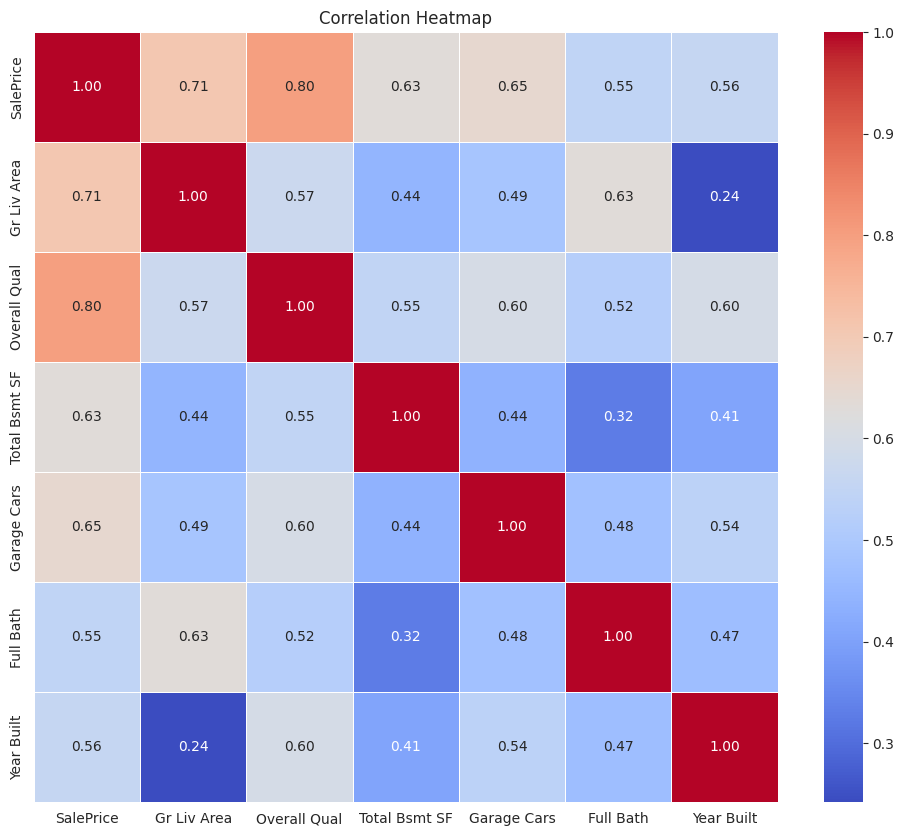

In [25]:
generate_ch(imp_df)

Here, its reverse. ***Red*** shows **perfect positive correlation** and ***dark blue*** shows **negative correlation**.

### Pairplot

In [26]:
def generate_pp(df: pd.DataFrame):
    sns.pairplot(df)
    plt.suptitle("Pair Plot of Selected Features", y=1.02)
    plt.show()

In [27]:
selected_features = df[['SalePrice', 'Gr Liv Area', 'Overall Qual', 'Total Bsmt SF', 'Year Built']]

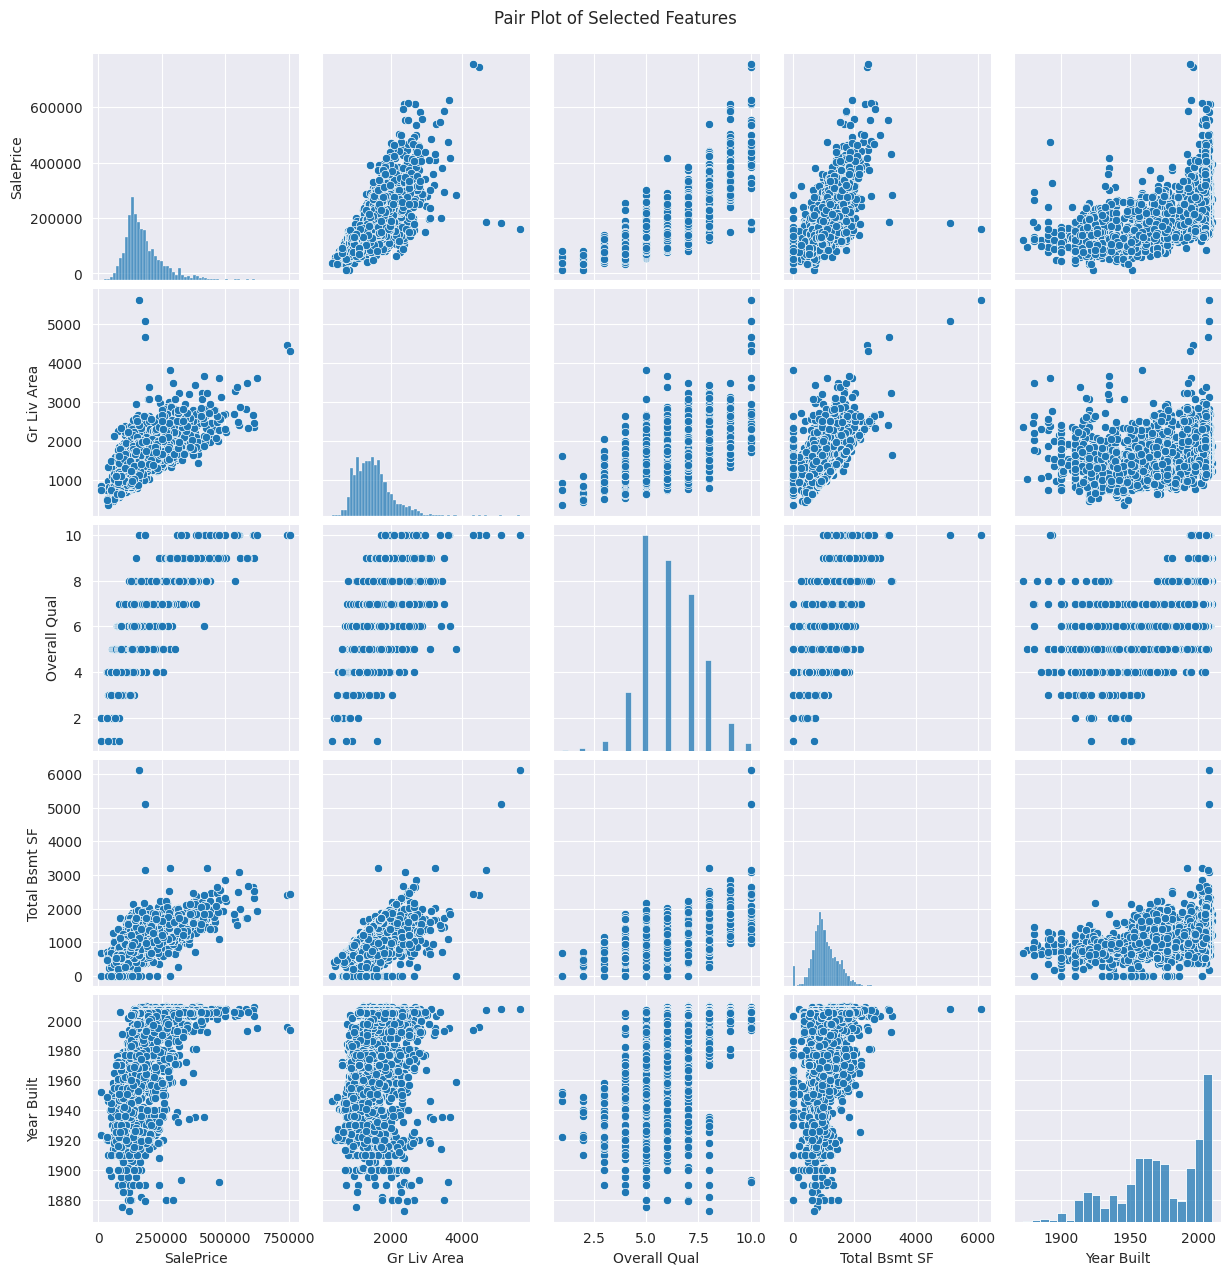

In [28]:
generate_pp(selected_features)

<a href="#toc" style="background-color:red; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="4.7"></a>
## <b><span style='color:red'>Insights-III</span></b>

#### **5. Correlation Heatmap:**
1. **SalePrice and Overall Qual**:
   - **Insight**: The highest correlation observed is between `SalePrice` and `Overall Qual` (0.80). This strong positive correlation indicates that the overall quality of the house is a significant determinant of its price. 
   - **Implication**: `Overall Qual` should be considered a key predictor in the model. The high correlation suggests that this feature explains a substantial portion of the variance in house prices.

2. **SalePrice and Gr Liv Area**:
   - **Insight**: The correlation between `SalePrice` and `Gr Liv Area` (0.71) is also strong, indicating that larger homes generally have higher sale prices.
   - **Implication**: Similar to `Overall Qual`, `Gr Liv Area` is another critical predictor of `SalePrice`. This relationship aligns with the expectation that more living space increases a property's value.

3. **Total Bsmt SF**:
   - **Insight**: The correlation between `Total Bsmt SF` and `SalePrice` (0.63) is moderate, suggesting that the size of the basement contributes to the overall value but not as strongly as living area or quality.
   - **Implication**: `Total Bsmt SF` is an important feature, but it may require further exploration or interaction with other features to capture its full effect.

4. **Year Built**:
   - **Insight**: `Year Built` has a lower correlation with `SalePrice` (0.56). While newer homes tend to sell for more, this relationship is less pronounced than those with living area or quality.
   - **Implication**: The age of the house is a relevant factor but might be more meaningful when combined with other features like `Overall Qual` or `Remod/Add Year`.

#### **6. Pair Plot:**
1. **Linear Relationships**:
   - **Insight**: The pair plots confirm linear relationships between `SalePrice` and both `Gr Liv Area` and `Total Bsmt SF`, supporting their inclusion as linear predictors in the model.
   - **Implication**: These linear relationships suggest that linear models (or transformations) could effectively capture these predictors' contributions to `SalePrice`.

2. **Discrete Distribution of Overall Qual**:
   - **Insight**: `Overall Qual` appears as a discrete variable in the pair plots, with significant gaps between categories. This suggests that it is more ordinal in nature.
   - **Implication**: Given its ordinal nature, `Overall Qual` might be better treated as a categorical variable with ordered categories. This could improve the interpretability and performance of the model.

3. **Potential Multicollinearity**:
   - **Insight**: The strong correlations between `Gr Liv Area`, `Overall Qual`, and `Total Bsmt SF` suggest potential multicollinearity, which could inflate variance in model coefficients.
   - **Implication**: Multicollinearity should be checked using Variance Inflation Factor (VIF) analysis. If multicollinearity is confirmed, techniques like feature selection, regularization, or Principal Component Analysis (PCA) might be needed.


<a href="#toc" style="background-color:red; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="4.8"></a>
## <b><span style='color:red'>Missing Value Analysis</span></b>

*Understanding missing values is crucial before applying any modeling or imputation. Below we analyze the count and percentage of missing data, followed by visualizations to help identify patterns or clusters of missingness.*

In [29]:
# Identifying missing values
seek_mv = df.isnull()
seek_mv

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,False,False,False,False,False,False,False,True,False,False,...,False,True,True,True,False,False,False,False,False,False
1,False,False,False,False,False,False,False,True,False,False,...,False,True,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,...,False,True,True,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,...,False,True,True,True,False,False,False,False,False,False
4,False,False,False,False,False,False,False,True,False,False,...,False,True,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,False,False,False,False,False,False,False,True,False,False,...,False,True,False,True,False,False,False,False,False,False
2926,False,False,False,False,True,False,False,True,False,False,...,False,True,False,True,False,False,False,False,False,False
2927,False,False,False,False,False,False,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False
2928,False,False,False,False,False,False,False,True,False,False,...,False,True,True,True,False,False,False,False,False,False


In [30]:
missing_values = seek_mv.sum()
missing_data = missing_values[missing_values>0]
missing_data

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

In [31]:
def get_missing_info(df: pd.DataFrame, top_n: int = 30) -> pd.DataFrame:
    """
    Returns a DataFrame with total and percent of missing values per feature.
    Only features with missing values are shown.
    """
    missing_total = df.isnull().sum()
    missing_percent = (missing_total / df.shape[0]) * 100
    missing_df = pd.DataFrame({
        'Total': missing_total,
        'Percent': missing_percent
    })
    missing_df = missing_df[missing_df.Total > 0].sort_values(by='Percent', ascending=False)
    return missing_df.head(top_n)

# Compute and display missing info
missing_df = get_missing_info(df)
missing_df

,Total,Percent
Pool QC,2917,99.556
Misc Feature,2824,96.382
Alley,2732,93.242
Fence,2358,80.478
Mas Vnr Type,1775,60.580
Fireplace Qu,1422,48.532
Lot Frontage,490,16.724
Garage Cond,159,5.427
Garage Qual,159,5.427
Garage Finish,159,5.427


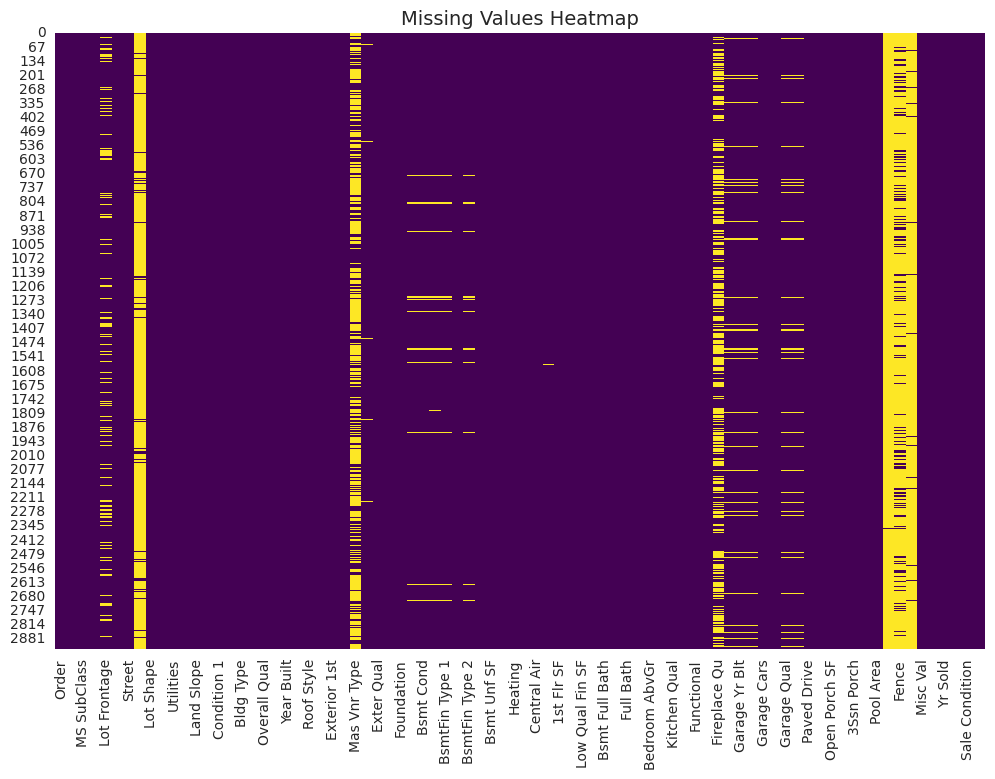

In [32]:
# Visual: Heatmap of Missingness
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap", fontsize=14)
plt.show()

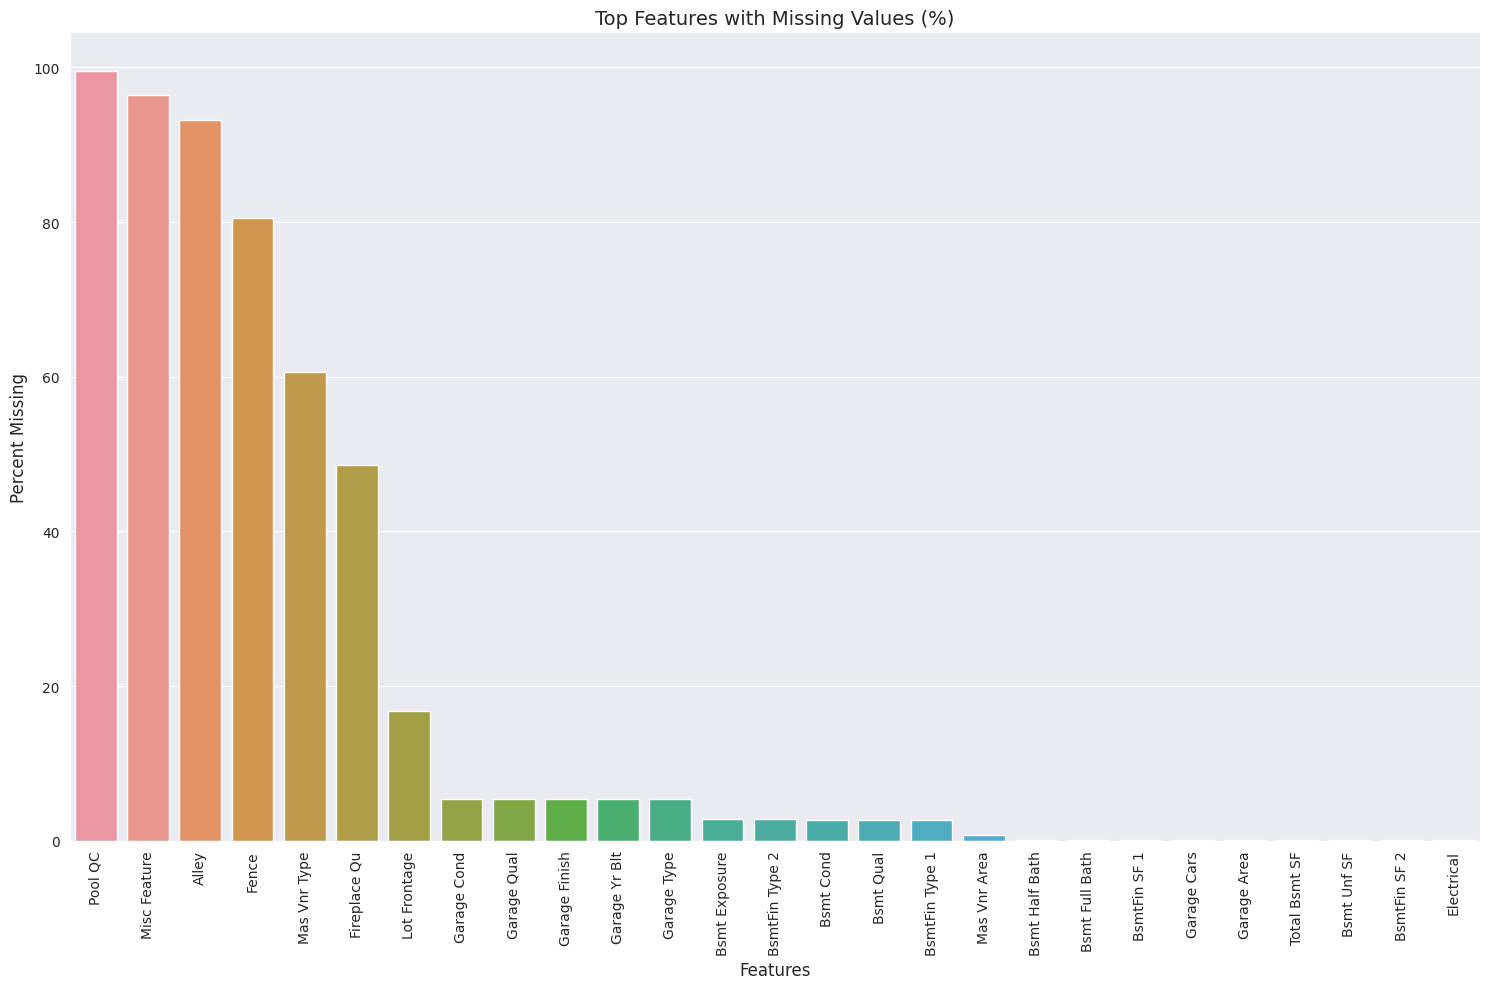

In [33]:
# Visual: Barplot of Missing % by Feature
plt.figure(figsize=(15, 10))
sns.barplot(x=missing_df.index, y=missing_df['Percent'])
plt.xticks(rotation=90)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Percent Missing', fontsize=12)
plt.title('Top Features with Missing Values (%)', fontsize=14)
plt.tight_layout()
plt.show()

<a href="#toc" style="background-color:red; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="4.9"></a>
## <b><span style='color:red'>Insights-IV</span></b>

#### **7. Missing Values Analysis:**
- **Columns with Significant Missing Values**:
  - `Alley` has **2732 missing values** (93.2% missing), making it almost unusable without imputation or transformation.
  - `Pool QC` (pool quality) has **2917 missing values** (99.5% missing), indicating that very few houses have pools.
  - `Fence` has **2358 missing values** (80.5% missing), suggesting that many houses do not have a fence or it was not recorded.
  - `Misc Feature` has **2824 missing values** (96.4% missing), indicating that most houses do not have miscellaneous features, or they were not recorded.

- **Columns with Moderate Missing Values**:
  - `Garage Type`, `Garage Yr Blt`, `Garage Finish`, `Garage Qual`, `Garage Cond` each have **159 missing values** (~5.4%), likely corresponding to houses without garages.
  - `Bsmt Qual`, `Bsmt Cond`, `Bsmt Exposure`, `BsmtFin Type 1`, `BsmtFin Type 2` each have **around 80 missing values** (~2.7%), likely representing houses without basements.
  - `Mas Vnr Type` (masonry veneer type) has **1775 missing values** (~60.6%), and `Mas Vnr Area` has **23 missing values**. This might indicate many houses do not have masonry veneer.

- **Single Missing Values**:
  - Several features, such as `BsmtFin SF 1`, `Total Bsmt SF`, `Electrical`, `Garage Cars`, `Garage Area`, etc., have only one or two missing values, which can likely be imputed without much impact.
 

#### Issues that must be addressed
1. **Handling Missing Data:**
   - **Significant Missing Values**: Columns like `Alley`, `Pool QC`, `Fence`, and `Misc Feature` have a very high percentage of missing data. Decisions need to be made whether to:
     - Drop these columns entirely, as they might not add significant value.
     - Impute missing values with a placeholder (e.g., "None" or "No Pool") to retain them in the analysis.
   - **Moderate Missing Values**: Features related to basements and garages will require careful handling. Missing values could be filled with "No Basement" or "No Garage" for categorical features, and zeros for numerical ones.
   - **Single Missing Values**: These can likely be filled with the mode or mean for categorical and numerical features, respectively.

2. **Categorical Encoding**:
   - Categorical features like `Neighborhood`, `MS Zoning`, `Bldg Type`, and `Exterior 1st` have many unique values. Decisions need to be made on how to encode these (e.g., one-hot encoding, label encoding, or frequency encoding) based on their relationship with the target variable.

3. **Multicollinearity**:
   - **Issue**: The high correlations between key predictors could lead to multicollinearity in regression models, which could skew the results and reduce model interpretability.
   - **Action**: Conduct VIF analysis to check for multicollinearity. If detected, consider removing or combining correlated features, using regularization techniques, or applying PCA to reduce dimensionality.

4. **Feature Engineering**:
   - **Issue**: Features like `Overall Qual`, which is ordinal, might benefit from specific treatment (e.g., encoding as an ordinal variable) rather than being treated as continuous.
   - **Action**: Consider encoding `Overall Qual` as an ordinal variable. Also, explore interactions between features like `Gr Liv Area` and `Total Bsmt SF` to capture more complex relationships.

5. **Outliers**:
   - **Issue**: The pair plots indicate potential outliers, especially in `Gr Liv Area` and `SalePrice`. These could be high-leverage points that unduly influence model performance.
   - **Action**: Identify and analyze outliers to determine if they should be removed or if the model should be adjusted to account for them (e.g., using robust regression techniques).

<a id="toc"></a>

<a href="#toc" style="background-color: red; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="5"></a>
# <b><span style='color:red'>Modeling</span></b>

<a id="5.1"></a>
## <b><span style='color:red'>Pipeline-I</span></b>

In [34]:
# === modeling pipeline 1 ===
pd.set_option('display.float_format', lambda x: '{:.5f}'.format(x))
model_results_log = []  # global container to store results

def load_data(filepath: str) -> pd.DataFrame:
    return pd.read_csv(filepath)


def handle_missing_values(df: pd.DataFrame, strategy: str = "mean") -> pd.DataFrame:
    cleaned_df=df.copy()
    numeric_columns = cleaned_df.select_dtypes(include="number").columns
    cleaned_df[numeric_columns] = cleaned_df[numeric_columns].fillna(
        df[numeric_columns].mean()
    )
    
    # missing_values = cleaned_df.isnull().sum()
    # missing_data = missing_values[missing_values>0]
    # print("\nMissing Values reamining yet\n", missing_data)
    return cleaned_df


def feature_transform(df: pd.DataFrame, features: List[str]) -> pd.DataFrame:
    df_transformed = df.copy()
    for feature in features:
        df_transformed[feature] = np.log1p(
            df[feature]
        )  # log1p handles log(0) by calculating log(1+x)
    return df_transformed


def detect_outliers(df: pd.DataFrame) -> pd.DataFrame:
    z_scores = np.abs((df - df.mean()) / df.std())
    outliers = z_scores > 3
    return outliers

def manage_outliers(df: pd.DataFrame, method="remove", **kwargs) -> pd.DataFrame:
    outliers = detect_outliers(df)
    if method == "remove":
        df_cleaned = df[(~outliers).all(axis=1)]
    elif method == "cap":
        df_cleaned = df.clip(lower=df.quantile(0.01), upper=df.quantile(0.99), axis=1)
    return df_cleaned
    
def handle_outliers(df: pd.DataFrame, column_name: str) -> pd.DataFrame:
    # Ensure only numeric columns are passed
    df_numeric = df.select_dtypes(include=[int, float])
    df_categorical = df.select_dtypes(include=[object])
    outliers = detect_outliers(df_numeric)
    df_cleaned = manage_outliers(df_numeric)
    
    return df_cleaned

def split_data(df: pd.DataFrame, target_column: str) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    X = df.drop(columns=[target_column])
    y = df[target_column]
    return train_test_split(X, y, test_size=0.2, random_state=42)


def build_pipeline(X_train: pd.DataFrame, model: RegressorMixin) -> Pipeline:
    categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns
    numerical_cols = X_train.select_dtypes(exclude=["object", "category"]).columns

    num_transform = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", RobustScaler())
    ])
    cat_transform = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", num_transform, numerical_cols),
        ("cat", cat_transform, categorical_cols)
    ])

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])


def evaluate_model(model: RegressorMixin, X_test: pd.DataFrame, y_test: pd.Series) -> dict:
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return {"MSE": mse, "RMSE": rmse, "R2": r2}


def run_model_pipeline(
    model: RegressorMixin,
    name: str = "Model",
    filepath: str = "/kaggle/input/ames-housing-dataset/AmesHousing.csv",
    target: str = "SalePrice"
) -> dict:
    print(f"\n===== {name} Pipeline =====")
    df = load_data(filepath)
    df = handle_missing_values(df)
    df = feature_transform(df, features=["Gr Liv Area", target])
    print("\nShape after feature engineering:\n",df.shape)
    df = handle_outliers(df, column_name="SalePrice")
    print("\nShape after outlier handling\n",df.shape)

    X_train, X_test, y_train, y_test = split_data(df, target)
    print("\nSize of xtrain: ",X_train.shape)
    print("\nSize of xtest: ",X_test.shape)
    pipeline = build_pipeline(X_train, model)
    pipeline.fit(X_train, y_train)

    X_test_processed = pipeline.named_steps["preprocessor"].transform(X_test)
    result = evaluate_model(pipeline.named_steps["model"], X_test_processed, y_test)
    print("\nEvaluation:", result)
    
    # Log result
    model_results_log.append({"Model": name, **result})
    return result


def get_model_results_summary() -> pd.DataFrame:
    return pd.DataFrame(model_results_log)

<a id="5.1.1"></a>
### <b><span style='color:red'>Model-I (Simple Linear Regression Starter)</span></b>

In [35]:
# Run Model-I
lr_result = run_model_pipeline(LinearRegression(), name="Linear Regression")


===== Linear Regression Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 39)

Size of xtrain:  (1646, 38)

Size of xtest:  (412, 38)

Evaluation: {'MSE': 0.01094236702299915, 'RMSE': 0.10460576954928992, 'R2': 0.9221139768587834}


#### **Basic baseline**

<a id="5.1.2"></a>
### <b><span style='color:red'>Model-II (Lasso)</span></b>

In [36]:
# Run Model-II
lasso_result = run_model_pipeline(Lasso(alpha=0.0005), name="Lasso Regression")


===== Lasso Regression Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 39)

Size of xtrain:  (1646, 38)

Size of xtest:  (412, 38)

Evaluation: {'MSE': 0.011032714278646152, 'RMSE': 0.1050367282365847, 'R2': 0.9214708995036484}


#### **Similar to Linear, slight higher `RMSE`**

<a id="5.1.3"></a>
### <b><span style='color:red'>Model-III (Elastic Net)</span></b>

In [37]:
# Run Model-III
ENet_result = run_model_pipeline(ElasticNet(alpha=0.0005, l1_ratio=.9, random_state=3), name="Elastic Net Regression")


===== Elastic Net Regression Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 39)

Size of xtrain:  (1646, 38)

Size of xtest:  (412, 38)

Evaluation: {'MSE': 0.011022836748672306, 'RMSE': 0.10498969829784399, 'R2': 0.9215412061865171}


#### **Similar to Linear, slight higher `RMSE`**

<a id="5.1.4"></a>
### <b><span style='color:red'>Model-IV (Kernel Ridge Regressor)</span></b>

In [38]:
# Run Model-IV
krr_result = run_model_pipeline(KernelRidge(alpha=0.6, kernel='polynomial', degree=2, coef0=2.5), name="Kernel Ridge Regression")


===== Kernel Ridge Regression Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 39)

Size of xtrain:  (1646, 38)

Size of xtest:  (412, 38)

Evaluation: {'MSE': 0.030380694357133513, 'RMSE': 0.17430058622142816, 'R2': 0.7837550633448431}


#### **❌ Underfit and poor generalization**

<a id="5.1.5"></a>
### <b><span style='color:red'>Model-V (Gradient Boosting Regressor)</span></b>

In [39]:
# Run Model-V
gbr_model = GradientBoostingRegressor(n_estimators=3000, learning_rate=0.05,
                                   max_depth=4, max_features='sqrt',
                                   min_samples_leaf=15, min_samples_split=10, 
                                   loss='huber', random_state =5)
gbr_result = run_model_pipeline(gbr_model, name="Gradient Boosting Regression")


===== Gradient Boosting Regression Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 39)

Size of xtrain:  (1646, 38)

Size of xtest:  (412, 38)

Evaluation: {'MSE': 0.01143421980673354, 'RMSE': 0.10693091137147172, 'R2': 0.9186130471956228}


#### **Poor generalization**

<a id="5.1.6"></a>
### <b><span style='color:red'>Model-VI (XGBoost Regressor)</span></b>

In [40]:
# Run Model-VI
xgb_model = XGBRegressor(colsample_bytree=0.4603, gamma=0.0468, 
                             learning_rate=0.05, max_depth=3, 
                             min_child_weight=1.7817, n_estimators=2200,
                             reg_alpha=0.4640, reg_lambda=0.8571,
                             subsample=0.5213, silent=1,
                             random_state =7, nthread = -1)
xgb_result = run_model_pipeline(xgb_model, name="XGBoost Regression")


===== XGBoost Regression Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 39)

Size of xtrain:  (1646, 38)

Size of xtest:  (412, 38)

Evaluation: {'MSE': 0.010866218629480093, 'RMSE': 0.10424115612117939, 'R2': 0.9226559889780375}


#### **Solid scores**

<a id="5.1.7"></a>
### <b><span style='color:red'>Model-VII (LightGBM Regressor)</span></b>

In [41]:
# Run Model-VII
lgb_model = LGBMRegressor(objective='regression',num_leaves=5,
                              learning_rate=0.05, n_estimators=720,
                              max_bin = 55, bagging_fraction = 0.8,
                              bagging_freq = 5, feature_fraction = 0.2319,
                              feature_fraction_seed=9, bagging_seed=9,
                              min_data_in_leaf =6, min_sum_hessian_in_leaf = 11)
lgb_result = run_model_pipeline(lgb_model, name="LightGBM Regression")


===== LightGBM Regression Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 39)

Size of xtrain:  (1646, 38)

Size of xtest:  (412, 38)
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_sampl

#### **Best solo in pipeline ✅**

<a id="5.1.8"></a>
### <b><span style='color:red'>Model-VIII (Averaging base models - ENet, LR, XGBR and LGBR)</span></b>

In [42]:
# Run Model-VIII
class AveragingModels(BaseEstimator, RegressorMixin, TransformerMixin):
    def __init__(self, models):
        self.models = models
        
    # we define clones of the original models to fit the data in
    def fit(self, X, y):
        self.models_ = [clone(x) for x in self.models]
        
        # Train cloned base models
        for model in self.models_:
            model.fit(X, y)

        return self
    
    #Now we do the predictions for cloned models and average them
    def predict(self, X):
        predictions = np.column_stack([
            model.predict(X) for model in self.models_
        ])
        return np.mean(predictions, axis=1)

ENet = ElasticNet(alpha=0.0005, l1_ratio=.9, random_state=3)
model_xgb = XGBRegressor(colsample_bytree=0.4603, gamma=0.0468, 
                             learning_rate=0.05, max_depth=3, 
                             min_child_weight=1.7817, n_estimators=2200,
                             reg_alpha=0.4640, reg_lambda=0.8571,
                             subsample=0.5213, silent=1,
                             random_state =7, nthread = -1)
model_lgb = LGBMRegressor(objective='regression',num_leaves=5,
                              learning_rate=0.05, n_estimators=720,
                              max_bin = 55, bagging_fraction = 0.8,
                              bagging_freq = 5, feature_fraction = 0.2319,
                              feature_fraction_seed=9, bagging_seed=9,
                              min_data_in_leaf =6, min_sum_hessian_in_leaf = 11)
lin_reg = LinearRegression()

model_combo = AveragingModels(models = (ENet, lin_reg, model_xgb, model_lgb))

avg_ensemble_result = run_model_pipeline(model_combo, name="Average Ensemble-I (enet,linear,xgb,lgb)")


===== Average Ensemble-I (enet,linear,xgb,lgb) Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 39)

Size of xtrain:  (1646, 38)

Size of xtest:  (412, 38)
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is s

#### **Strong `RMSE` and nice `R-squared`**

<a id="5.1.9"></a>
### <b><span style='color:red'>Model-IX (Averaging base models - LR, XGBR and LGBR)</span></b>

In [43]:
# Run Model-IX
model_combo_2 = AveragingModels(models = (lin_reg, model_xgb, model_lgb))

avg_ensemble_result = run_model_pipeline(model_combo_2, name="Average Ensemble-II (linear,xgb,lgb)")


===== Average Ensemble-II (linear,xgb,lgb) Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 39)

Size of xtrain:  (1646, 38)

Size of xtest:  (412, 38)
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6

#### **Slightly Better `RMSE` and nice `R-squared`**

<a id="5.1.10"></a>
### <b><span style='color:red'> MODEL-X (Stacking Ensemble)</span></b>

In [44]:
# Run Model-X
meta_model = lin_reg
stacked_model = StackingRegressor(
    estimators=[('xgb', model_xgb), ('lgb', model_lgb)],
    final_estimator=meta_model,
    passthrough=True
)

stacked_result = run_model_pipeline(stacked_model, name="Stacking Ensemble [(xgb,lgb),linear]")


===== Stacking Ensemble [(xgb,lgb),linear] Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 39)

Size of xtrain:  (1646, 38)

Size of xtest:  (412, 38)
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6

#### **🥇 Best `RMSE` overall**

<a id="5.1.11"></a>
### <b><span style='color:red'> Metric Figures for Pipeline-I Models</span></b>

In [45]:
display(get_model_results_summary())

,Model,MSE,RMSE,R2
0,Linear Regression,0.01094,0.10461,0.92211
1,Lasso Regression,0.01103,0.10504,0.92147
2,Elastic Net Regression,0.01102,0.10499,0.92154
3,Kernel Ridge Regression,0.03038,0.17430,0.78376
4,Gradient Boosting Regression,0.01143,0.10693,0.91861
5,XGBoost Regression,0.01087,0.10424,0.92266
6,LightGBM Regression,0.01057,0.10283,0.92473
7,"Average Ensemble-I (enet,linear,xgb,lgb)",0.00990,0.09951,0.92952
8,"Average Ensemble-II (linear,xgb,lgb)",0.00988,0.09940,0.92968
9,"Stacking Ensemble [(xgb,lgb),linear]",0.00973,0.09865,0.93074


<a href="#toc" style="background-color:red; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="5.2"></a>
## <b><span style='color:red'>Pipeline-II</span></b>

In [46]:
# === modeling pipeline 2 ===
model_results_log = []  # global container to store results

def load_data(filepath: str) -> pd.DataFrame:
    return pd.read_csv(filepath)


def handle_missing_values(df: pd.DataFrame, strategy: str = "mean") -> pd.DataFrame:
    df = df.copy()
    numeric_cols = df.select_dtypes(include="number").columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
    return df


def feature_transform(df: pd.DataFrame, features: List[str]) -> pd.DataFrame:
    df = df.copy()
    for feature in features:
        df[feature] = np.log1p(df[feature])
    return df


def detect_outliers(df: pd.DataFrame, z_thresh: float = 3.0) -> pd.DataFrame:
    z_scores = np.abs((df - df.mean()) / df.std())
    return z_scores > z_thresh


def handle_outliers(df: pd.DataFrame, method: str = "remove") -> pd.DataFrame:
    numeric_df = df.select_dtypes(include=[np.number])
    outliers = detect_outliers(numeric_df)
    
    if method == "remove":
        cleaned = df.loc[(~outliers).all(axis=1)]
    elif method == "cap":
        capped = numeric_df.clip(lower=numeric_df.quantile(0.01), upper=numeric_df.quantile(0.99), axis=1)
        cleaned = df.copy()
        cleaned[numeric_df.columns] = capped
    else:
        cleaned = df
    
    return cleaned

def split_data(df: pd.DataFrame, target_column: str) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    X = df.drop(columns=[target_column])
    y = df[target_column]
    return train_test_split(X, y, test_size=0.2, random_state=42)


def build_pipeline(X_train: pd.DataFrame, model: RegressorMixin) -> Pipeline:
    categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns
    numerical_cols = X_train.select_dtypes(exclude=["object", "category"]).columns

    num_transform = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", RobustScaler())
    ])
    cat_transform = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", num_transform, numerical_cols),
        ("cat", cat_transform, categorical_cols)
    ])

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])


def evaluate_model(model: RegressorMixin, X_test: pd.DataFrame, y_test: pd.Series) -> dict:
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return {"MSE": mse, "RMSE": rmse, "R2": r2}


def run_model_pipeline(
    model: RegressorMixin,
    name: str = "Model",
    filepath: str = "/kaggle/input/ames-housing-dataset/AmesHousing.csv",
    target: str = "SalePrice"
) -> dict:
    print(f"\n===== {name} Pipeline =====")
    df = load_data(filepath)
    df = handle_missing_values(df)
    df = feature_transform(df, features=["Gr Liv Area", target])
    print("\nShape after feature engineering:\n",df.shape)
    
    df = handle_outliers(df, method="remove")
    print("\nShape after outlier handling\n",df.shape)

    X_train, X_test, y_train, y_test = split_data(df, target)
    print("\nSize of xtrain: ",X_train.shape)
    print("\nSize of xtest: ",X_test.shape)
    
    pipeline = build_pipeline(X_train, model)
    pipeline.fit(X_train, y_train)

    X_test_processed = pipeline.named_steps["preprocessor"].transform(X_test)
    result = evaluate_model(pipeline.named_steps["model"], X_test_processed, y_test)
    print("Evaluation:", result)
    
    # Log result
    model_results_log.append({"Model": name, **result})
    return result

def get_model_results_log() -> pd.DataFrame:
    return pd.DataFrame(model_results_log)

In [47]:
# Run Model-I
lr_result = run_model_pipeline(LinearRegression(), name="Model-I: Linear Regression")


===== Model-I: Linear Regression Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 82)

Size of xtrain:  (1646, 81)

Size of xtest:  (412, 81)
Evaluation: {'MSE': 0.00917131632742616, 'RMSE': 0.09576698975861234, 'R2': 0.934720033223895}


In [48]:
# Run Model-II
lasso_result = run_model_pipeline(Lasso(alpha=0.0005), name="Model-II: Lasso")


===== Model-II: Lasso Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 82)

Size of xtrain:  (1646, 81)

Size of xtest:  (412, 81)
Evaluation: {'MSE': 0.00795460731761824, 'RMSE': 0.08918860531266447, 'R2': 0.9433803738882911}


In [49]:
# Run Model-III
enet_result = run_model_pipeline(ElasticNet(alpha=0.0005, l1_ratio=.9, random_state=3), name="Model-III: Elastic Net")


===== Model-III: Elastic Net Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 82)

Size of xtrain:  (1646, 81)

Size of xtest:  (412, 81)
Evaluation: {'MSE': 0.007926880277677373, 'RMSE': 0.08903302913906375, 'R2': 0.9435777305360742}


In [50]:
# Run Model-IV
krr_result = run_model_pipeline(KernelRidge(alpha=0.6, kernel='polynomial', degree=2, coef0=2.5), name="Model-IV: Kernel Ridge")


===== Model-IV: Kernel Ridge Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 82)

Size of xtrain:  (1646, 81)

Size of xtest:  (412, 81)
Evaluation: {'MSE': 0.01252767728199865, 'RMSE': 0.11192710700272142, 'R2': 0.9108299912952467}


In [51]:
# Run Model-V
gbr_model = GradientBoostingRegressor(n_estimators=3000, learning_rate=0.05,
                                   max_depth=4, max_features='sqrt',
                                   min_samples_leaf=15, min_samples_split=10, 
                                   loss='huber', random_state =5)
gbr_result = run_model_pipeline(gbr_model, name="Model-V: Gradient Boosting")


===== Model-V: Gradient Boosting Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 82)

Size of xtrain:  (1646, 81)

Size of xtest:  (412, 81)
Evaluation: {'MSE': 0.00930196803623434, 'RMSE': 0.09644671086270562, 'R2': 0.9337900751997961}


In [52]:
# Run Model-VI
xgb_model = XGBRegressor(colsample_bytree=0.4603, gamma=0.0468, 
                             learning_rate=0.05, max_depth=3, 
                             min_child_weight=1.7817, n_estimators=2200,
                             reg_alpha=0.4640, reg_lambda=0.8571,
                             subsample=0.5213, silent=1,
                             random_state =7, nthread = -1)
xgb_result = run_model_pipeline(xgb_model, name="Model-VI: XGBoost")


===== Model-VI: XGBoost Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 82)

Size of xtrain:  (1646, 81)

Size of xtest:  (412, 81)
Evaluation: {'MSE': 0.008689948749608331, 'RMSE': 0.09321989460200183, 'R2': 0.938146330863752}


In [53]:
# Run Model-VII
lgb_model = LGBMRegressor(objective='regression',num_leaves=5,
                              learning_rate=0.05, n_estimators=720,
                              max_bin = 55, bagging_fraction = 0.8,
                              bagging_freq = 5, feature_fraction = 0.2319,
                              feature_fraction_seed=9, bagging_seed=9,
                              min_data_in_leaf =6, min_sum_hessian_in_leaf = 11)
lgb_result = run_model_pipeline(lgb_model, name="Model-VII: LightGBM")


===== Model-VII: LightGBM Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 82)

Size of xtrain:  (1646, 81)

Size of xtest:  (412, 81)
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_sampl

In [54]:
# Run Model-VIII
class AveragingModels(BaseEstimator, RegressorMixin, TransformerMixin):
    def __init__(self, models):
        self.models = models
        
    # we define clones of the original models to fit the data in
    def fit(self, X, y):
        self.models_ = [clone(x) for x in self.models]
        
        # Train cloned base models
        for model in self.models_:
            model.fit(X, y)

        return self
    
    #Now we do the predictions for cloned models and average them
    def predict(self, X):
        predictions = np.column_stack([
            model.predict(X) for model in self.models_
        ])
        return np.mean(predictions, axis=1)

ENet = ElasticNet(alpha=0.0005, l1_ratio=.9, random_state=3)
model_xgb = XGBRegressor(colsample_bytree=0.4603, gamma=0.0468, 
                             learning_rate=0.05, max_depth=3, 
                             min_child_weight=1.7817, n_estimators=2200,
                             reg_alpha=0.4640, reg_lambda=0.8571,
                             subsample=0.5213, silent=1,
                             random_state =7, nthread = -1)
model_lgb = LGBMRegressor(objective='regression',num_leaves=5,
                              learning_rate=0.05, n_estimators=720,
                              max_bin = 55, bagging_fraction = 0.8,
                              bagging_freq = 5, feature_fraction = 0.2319,
                              feature_fraction_seed=9, bagging_seed=9,
                              min_data_in_leaf =6, min_sum_hessian_in_leaf = 11)
lin_reg = LinearRegression()

model_combo = AveragingModels(models = (ENet, lin_reg, model_xgb, model_lgb))

avg_ensemble_result = run_model_pipeline(model_combo, name="Model-VIII: Average Ensemble(enet,linear,xgb,lgb)")


===== Model-VIII: Average Ensemble(enet,linear,xgb,lgb) Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 82)

Size of xtrain:  (1646, 81)

Size of xtest:  (412, 81)
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_

In [55]:
# Run Model-IX
model_combo_2 = AveragingModels(models = (lin_reg, model_xgb, model_lgb))

avg_ensemble_result = run_model_pipeline(model_combo_2, name="Model-IX: Average Ensemble(linear,xgb,lgb)")


===== Model-IX: Average Ensemble(linear,xgb,lgb) Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 82)

Size of xtrain:  (1646, 81)

Size of xtest:  (412, 81)
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is

In [56]:
# Run Model-X
meta_model = lin_reg
stacked_model = StackingRegressor(
    estimators=[('xgb', model_xgb), ('lgb', model_lgb)],
    final_estimator=meta_model,
    passthrough=True
)

stacked_result = run_model_pipeline(stacked_model, name="Model-X: Stacking Ensemble[(xgb,lgb),linear]")


===== Model-X: Stacking Ensemble[(xgb,lgb),linear] Pipeline =====

Shape after feature engineering:
 (2930, 82)

Shape after outlier handling
 (2058, 82)

Size of xtrain:  (1646, 81)

Size of xtest:  (412, 81)
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf 

<a id="5.2.1"></a>
### <b><span style='color:red'> Metric Figures for Pipeline-II Models</span></b>

In [57]:
display(get_model_results_log())

,Model,MSE,RMSE,R2
0,Model-I: Linear Regression,0.00917,0.09577,0.93472
1,Model-II: Lasso,0.00795,0.08919,0.94338
2,Model-III: Elastic Net,0.00793,0.08903,0.94358
3,Model-IV: Kernel Ridge,0.01253,0.11193,0.91083
4,Model-V: Gradient Boosting,0.00930,0.09645,0.93379
5,Model-VI: XGBoost,0.00869,0.09322,0.93815
6,Model-VII: LightGBM,0.00839,0.09157,0.94031
7,"Model-VIII: Average Ensemble(enet,linear,xgb,lgb)",0.00738,0.08590,0.94748
8,"Model-IX: Average Ensemble(linear,xgb,lgb)",0.00753,0.08677,0.94641
9,"Model-X: Stacking Ensemble[(xgb,lgb),linear]",0.00911,0.09543,0.93517


<a href="#toc" style="background-color:red; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="5.3"></a>
## <b><span style='color:red'>Pipeline-III</span></b>

In [58]:
all_data = df.copy()

<a id="5.3.1"></a>
### <b><span style='color:red'>Ouliers and Target Variable</span></b>

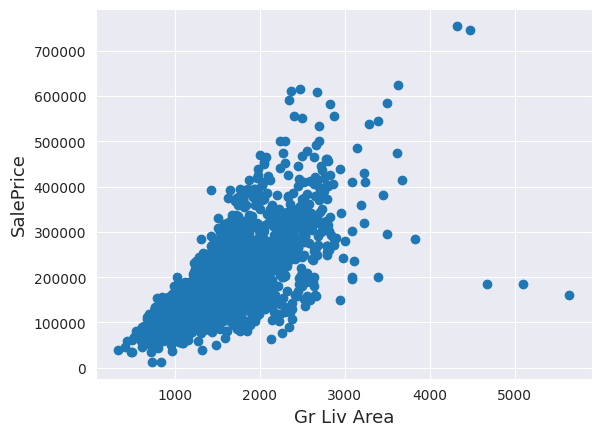

In [59]:
# outliers
fig, ax = plt.subplots()
ax.scatter(x = all_data['Gr Liv Area'], y = all_data['SalePrice'])
plt.ylabel('SalePrice', fontsize=13)
plt.xlabel('Gr Liv Area', fontsize=13)
plt.show()

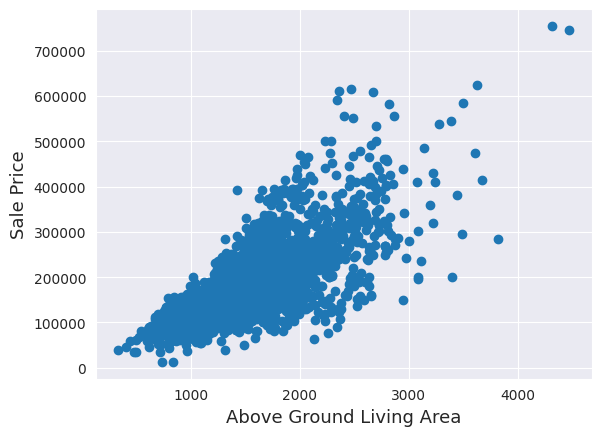

In [60]:
#Deleting outliers
all_data = all_data.drop(df[(df['Gr Liv Area']>4000) & (df['SalePrice']<200000)].index)

#Check the graphic again
fig, ax = plt.subplots()
ax.scatter(x = all_data['Gr Liv Area'], y = all_data['SalePrice'])
plt.ylabel('Sale Price', fontsize=13)
plt.xlabel('Above Ground Living Area', fontsize=13)
plt.show()


 mu = 180796.06 and sigma = 79873.06



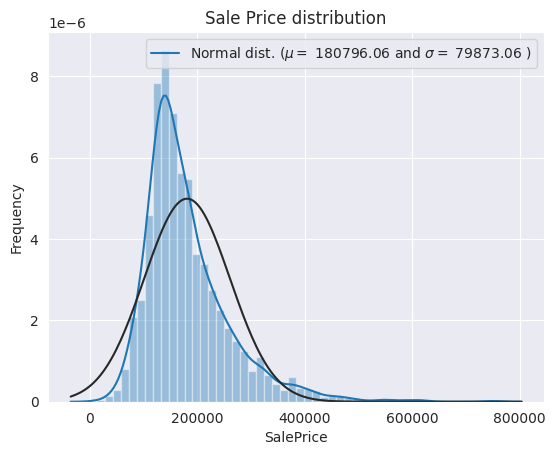

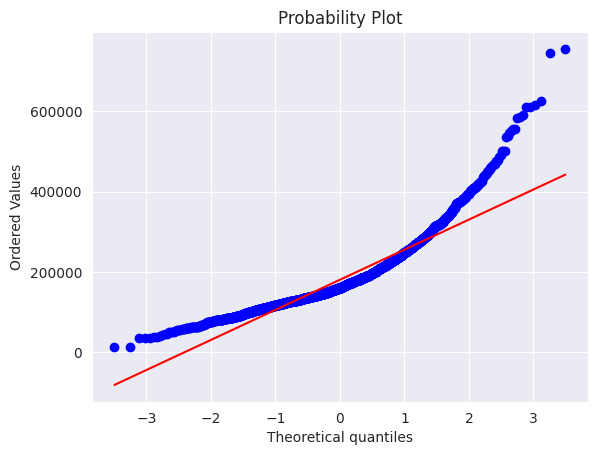

In [61]:
# target variable distribution
sns.distplot(all_data['SalePrice'] , fit=norm);

# Get the fitted parameters used by the function
(mu, sigma) = norm.fit(df['SalePrice'])
print( '\n mu = {:.2f} and sigma = {:.2f}\n'.format(mu, sigma))

#Now plot the distribution
plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],
            loc='best')
plt.ylabel('Frequency')
plt.title('Sale Price distribution')

#Get also the QQ-plot
fig = plt.figure()
res = stats.probplot(df['SalePrice'], plot=plt)
plt.show()


 mu = 12.0209 and sigma = 0.4077



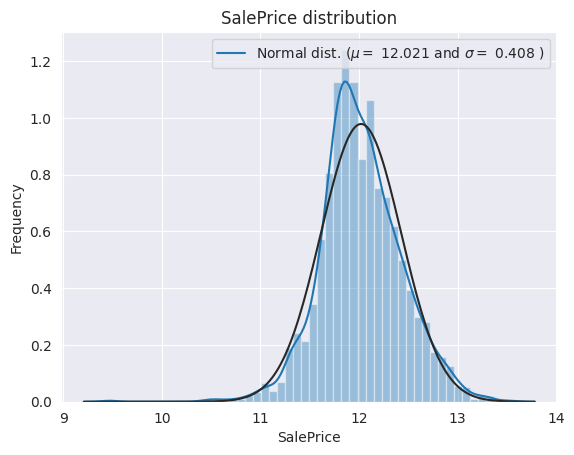

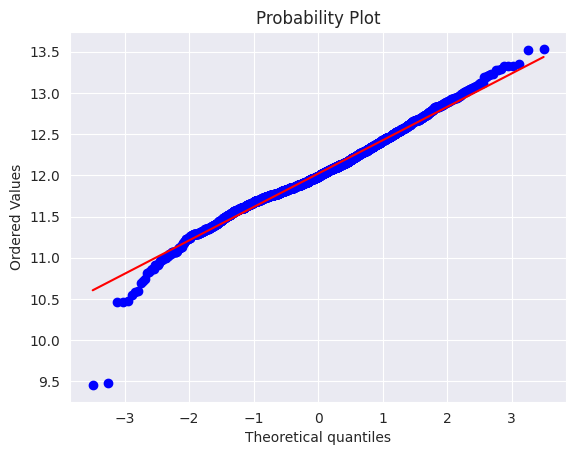

In [62]:
# Log transformation of target variable
all_data["SalePrice"] = np.log1p(all_data["SalePrice"])

#Check the new distribution 
sns.distplot(all_data['SalePrice'] , fit=norm);

# Get the fitted parameters used by the function
(mu, sigma) = norm.fit(all_data['SalePrice'])
print( '\n mu = {:.4f} and sigma = {:.4f}\n'.format(mu, sigma))

#Now plot the distribution
plt.legend(['Normal dist. ($\mu=$ {:.3f} and $\sigma=$ {:.3f} )'.format(mu, sigma)],
            loc='best')
plt.ylabel('Frequency')
plt.title('SalePrice distribution')

#Get also the QQ-plot
fig = plt.figure()
res = stats.probplot(all_data['SalePrice'], plot=plt)
plt.show()

In [63]:
y = all_data.SalePrice.values
all_data.drop(['SalePrice'], axis=1, inplace=True)
print("All data size is : {}".format(all_data.shape))

All data size is : (2927, 81)


<a id="5.3.2"></a>
### <b><span style='color:red'>Handling Missing Values</span></b>

In [64]:
mv = all_data.isnull().sum()
df_na = (mv / len(all_data)) * 100
df_na = df_na.drop(df_na[df_na == 0].index).sort_values(ascending=False)[:30]
missing_df = pd.DataFrame({'Missing Ratio' :df_na})
missing_df.head(20)

,Missing Ratio
Pool QC,99.59002
Misc Feature,96.41271
Alley,93.23539
Fence,80.45781
Mas Vnr Type,60.64230
Fireplace Qu,48.58217
Lot Frontage,16.74069
Garage Cond,5.43218
Garage Qual,5.43218
Garage Finish,5.43218


In [65]:
missing_data

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

In [66]:
# df = df.drop((missing_df[missing_df['Total']>2]).index,axis=1)
# df.isnull().sum().max()

In [67]:
all_data['Pool QC'] = all_data['Pool QC'].fillna("None")
all_data['Misc Feature'] = all_data['Misc Feature'].fillna("None")
all_data["Alley"] = all_data["Alley"].fillna("None")
all_data["Fence"] = all_data["Fence"].fillna("None")
all_data["Fireplace Qu"] = all_data["Fireplace Qu"].fillna("None")
all_data["Mas Vnr Type"] = all_data["Mas Vnr Type"].fillna("None")
all_data["Mas Vnr Area"] = all_data["Mas Vnr Area"].fillna(0)
all_data["Lot Frontage"] = all_data.groupby("Neighborhood")["Lot Frontage"].transform(lambda x: x.fillna(x.median()))

for col in ('Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond'):
    all_data[col] = all_data[col].fillna('None')

for col in ('Garage Yr Blt', 'Garage Area', 'Garage Cars'):
    all_data[col] = all_data[col].fillna(0)

for col in ('BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF','Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath'):
    all_data[col] = all_data[col].fillna(0)

for col in ('Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2'):
    all_data[col] = all_data[col].fillna('None')

# all_data['MSZoning'] = all_data['MSZoning'].fillna(all_data['MSZoning'].mode()[0])
# all_data = all_data.drop(['Utilities'], axis=1)
# all_data["Functional"] = all_data["Functional"].fillna("Typ")
all_data['Electrical'] = all_data['Electrical'].fillna(all_data['Electrical'].mode()[0])
# all_data['KitchenQual'] = all_data['KitchenQual'].fillna(all_data['KitchenQual'].mode()[0])
# all_data['Exterior1st'] = all_data['Exterior1st'].fillna(all_data['Exterior1st'].mode()[0])
# all_data['Exterior2nd'] = all_data['Exterior2nd'].fillna(all_data['Exterior2nd'].mode()[0])
# all_data['SaleType'] = all_data['SaleType'].fillna(all_data['SaleType'].mode()[0])
# all_data['MSSubClass'] = all_data['MSSubClass'].fillna("None")

In [68]:
#Check remaining missing values if any 
all_data_na = (all_data.isnull().sum() / len(all_data)) * 100
all_data_na = all_data_na.drop(all_data_na[all_data_na == 0].index).sort_values(ascending=False)
missing_df = pd.DataFrame({'Missing Ratio' :all_data_na})
missing_df.head()

,Missing Ratio
Lot Frontage,0.10249


<a id="5.3.3"></a>
### <b><span style='color:red'>More Feature Engineering</span></b>

In [69]:
# Dropping one column
all_data = all_data.drop(['Utilities'], axis=1)

<a id="5.3.4"></a>
### <b><span style='color:red'>Feature Type Transform</span></b>

In [70]:
#MSSubClass=The building class
all_data['MS SubClass'] = all_data['MS SubClass'].apply(str)


#Changing OverallCond into a categorical variable
all_data['Overall Cond'] = all_data['Overall Cond'].astype(str)


#Year and month sold are transformed into categorical features.
all_data['Yr Sold'] = all_data['Yr Sold'].astype(str)
all_data['Mo Sold'] = all_data['Mo Sold'].astype(str)

<a id="5.3.5"></a>
### <b><span style='color:red'>Label Encoding</span></b>

In [71]:
from sklearn.preprocessing import LabelEncoder
cols = ('Fireplace Qu', 'Bsmt Qual', 'Bsmt Cond', 'Garage Qual', 'Garage Cond', 
        'Exter Qual', 'Exter Cond','Heating QC', 'Pool QC', 'Kitchen Qual', 'BsmtFin Type 1', 
        'BsmtFin Type 2', 'Functional', 'Fence', 'Bsmt Exposure', 'Garage Finish', 'Land Slope',
        'Lot Shape', 'Paved Drive', 'Street', 'Alley', 'Central Air', 'MS SubClass', 'Overall Cond', 
        'Yr Sold', 'Mo Sold')
# process columns, apply LabelEncoder to categorical features
for c in cols:
    lbl = LabelEncoder() 
    lbl.fit(list(all_data[c].values)) 
    all_data[c] = lbl.transform(list(all_data[c].values))

# shape        
print('Shape now: {}'.format(all_data.shape))

Shape now: (2927, 80)


In [72]:
# Adding total square footage feature
all_data['Total SF'] = all_data['Total Bsmt SF'] + all_data['1st Flr SF'] + all_data['2nd Flr SF']

<a id="5.3.6"></a>
### <b><span style='color:red'>Detecting Skewed Features</span></b>

In [73]:
numeric_feats = all_data.dtypes[all_data.dtypes != "object"].index
len(numeric_feats)

61

In [74]:
# Check the skew of all numerical features
skewed_feats = all_data[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
print("\nSkew in numerical features: \n")
skewness = pd.DataFrame({'Skew' :skewed_feats})
display(skewness)


Skew in numerical features: 



,Skew
Misc Val,22.22120
Pool Area,17.71925
Lot Area,13.17873
Low Qual Fin SF,12.10564
3Ssn Porch,11.39199
...,...
Garage Cond,-3.60178
Functional,-3.82498
Garage Yr Blt,-3.91258
Street,-15.52162


In [75]:
skewed = skewness[abs(skewness) > 0.75]

In [76]:
skewed = skewed['Skew'].dropna().sort_values(ascending=False)
display(skewed)

Misc Val           22.22120
Pool Area          17.71925
Lot Area           13.17873
Low Qual Fin SF    12.10564
3Ssn Porch         11.39199
Land Slope          4.98276
Kitchen AbvGr       4.30906
BsmtFin SF 2        4.13623
Enclosed Porch      4.01007
Screen Porch        3.95306
Bsmt Half Bath      3.95250
Mas Vnr Area        2.59886
Open Porch SF       2.49397
Wood Deck SF        1.84385
Lot Frontage        1.09862
Gr Liv Area         0.97609
1st Flr SF          0.95071
Bsmt Unf SF         0.92409
2nd Flr SF          0.86538
BsmtFin SF 1        0.83037
Bsmt Exposure      -1.10920
Exter Qual         -1.79117
Fence              -1.99561
Exter Cond         -2.50263
Bsmt Cond          -2.87237
Paved Drive        -2.98445
BsmtFin Type 2     -3.02844
Garage Qual        -3.07960
Central Air        -3.46489
Garage Cond        -3.60178
Functional         -3.82498
Garage Yr Blt      -3.91258
Street            -15.52162
Pool QC           -18.89908
Name: Skew, dtype: float64

In [77]:
print("There are {} skewed numerical features to transform".format(skewed.shape[0]))

There are 34 skewed numerical features to transform


In [78]:
# Applying box-cox transform
from scipy.special import boxcox1p
skewed_features = skewed.index
lam = 0.15
for feat in skewed_features:
    all_data[feat] = boxcox1p(all_data[feat], lam)

In [79]:
all_data.shape

(2927, 81)

In [80]:
final_data = pd.get_dummies(all_data)
final_data.shape

(2927, 231)

<a id="5.3.7"></a>
### <b><span style='color:red'>Assemble</span></b>

In [81]:
# Ready data
raw_data = final_data.copy()

# Handling Missing Values Left
def hmvl(df: pd.DataFrame, strategy: str = "mean") -> pd.DataFrame:
    cleaned_df=df.copy()
    numeric_columns = cleaned_df.select_dtypes(include="number").columns
    cleaned_df[numeric_columns] = cleaned_df[numeric_columns].fillna(
        df[numeric_columns].mean()
    )
    
    return cleaned_df

filled_data = hmvl(raw_data)

# Feature Engineering
def fes(
    df: pd.DataFrame, strategy: str = "log", features: list = None
) -> pd.DataFrame:
    df_transformed = df.copy()
    for feature in features:
        df_transformed[feature] = np.log1p(df[feature])
    return df_transformed

# Outlier Detection
def detect_outliers(df: pd.DataFrame) -> pd.DataFrame:
    z_scores = np.abs((df - df.mean()) / df.std())
    outliers = z_scores > 3
    return outliers

def handle_outliers(df: pd.DataFrame, method="remove", **kwargs) -> pd.DataFrame:
    outliers = detect_outliers(df)
    if method == "remove":
        df_cleaned = df[(~outliers).all(axis=1)]
    elif method == "cap":
        df_cleaned = df.clip(lower=df.quantile(0.01), upper=df.quantile(0.99), axis=1)
    return df_cleaned
            
def outlier_handling_step(df: pd.DataFrame, column_name: str) -> pd.DataFrame:    
    # Ensure only numeric columns are passed
    df_numeric = df.select_dtypes(include=[int, float])
    df_categorical = df.select_dtypes(include=[object])
    outliers = detect_outliers(df_numeric)
    df_cleaned = handle_outliers(df_numeric, method="remove")    
    return df_cleaned

# Data Splitting
X = filled_data
y = pd.Series(y)
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
print("\nSize of xtrain: ",X_train.shape)
print("\nSize of xtest: ",X_test.shape)

# Model Building
def model_building_step(
    X_train: pd.DataFrame, y_train: pd.Series
) -> Pipeline:
    """
    Builds and trains a Linear Regression model using scikit-learn wrapped in a pipeline.

    Parameters:
    X_train (pd.DataFrame): The training data features.
    y_train (pd.Series): The training data labels/target.

    Returns:
    Pipeline: The trained scikit-learn pipeline including preprocessing and the Linear Regression model.
    """
    # Ensure the inputs are of the correct type
    if not isinstance(X_train, pd.DataFrame):
        raise TypeError("X_train must be a pandas DataFrame.")
    if not isinstance(y_train, pd.Series):
        raise TypeError("y_train must be a pandas Series.")

    # Identify categorical and numerical columns
    categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns
    numerical_cols = X_train.select_dtypes(exclude=["object", "category"]).columns

    numerical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="mean")),
            # ("scaler", RobustScaler()),
        ]
    )
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            # ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    # Bundle preprocessing for numerical and categorical data
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numerical_transformer, numerical_cols),
            ("cat", categorical_transformer, categorical_cols),
        ]
    )

    # Define the model training pipeline
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", LinearRegression())])

    try:
        print("Building and training the Linear Regression model. ")
        pipeline.fit(X_train, y_train)
        print("Model training completed.")

    except Exception as e:
        raise e

    return pipeline
    
model = model_building_step(X_train=X_train, y_train=y_train)

# Model Evaluation
def evaluate_model(
    model: RegressorMixin, X_test: pd.DataFrame, y_test: pd.Series
) -> dict:
    """
    Evaluates a regression model using R-squared and Mean Squared Error.

    Parameters:
    model (RegressorMixin): The trained regression model to evaluate.
    X_test (pd.DataFrame): The testing data features.
    y_test (pd.Series): The testing data labels/target.

    Returns:
    dict: A dictionary containing R-squared and Mean Squared Error.
    """
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mse)

    metrics = {"Mean Squared Error": mse, "RMSE": rmse, "R-Squared": r2}
    return metrics

def model_evaluation_step(
    trained_model: Pipeline, X_test: pd.DataFrame, y_test: pd.Series
) -> Tuple[dict, float]:
    
    # Ensure the inputs are of the correct type
    if not isinstance(X_test, pd.DataFrame):
        raise TypeError("X_test must be a pandas DataFrame.")
    if not isinstance(y_test, pd.Series):
        raise TypeError("y_test must be a pandas Series.")

    # Apply the preprocessing and model prediction
    X_test_processed = trained_model.named_steps["preprocessor"].transform(X_test)

    # Perform the evaluation
    evaluation_metrics = evaluate_model(
        trained_model.named_steps["model"], X_test_processed, y_test
    )

    # Ensure that the evaluation metrics are returned as a dictionary
    if not isinstance(evaluation_metrics, dict):
        raise ValueError("Evaluation metrics must be returned as a dictionary.")
    mse = evaluation_metrics.get("Mean Squared Error", None)
    return evaluation_metrics, mse

eval_metrics, mse = model_evaluation_step(trained_model=model, X_test=X_test, y_test=y_test)

print("\n\n Metrics on Evaluation:\n",eval_metrics)


Size of xtrain:  (2341, 231)

Size of xtest:  (586, 231)
Building and training the Linear Regression model. 
Model training completed.


 Metrics on Evaluation:
 {'Mean Squared Error': 0.08362451568708824, 'RMSE': 0.28917903742679596, 'R-Squared': 0.5344386558115206}


#### **Low `RMSE` and `R-squared`**
This pipeline can be improved

<a href="#toc" style="background-color:red; color: #ffffff; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to top</a><a id="toc"></a>

<a id="5.4"></a>
## <b><span style='color:red'>Pipeline-IV</span></b>

In [82]:
# === modeling pipeline 4 ===
model_results = []  # to store model performances

# Data Ingestion Step
def ingest_data(filepath: str) -> pd.DataFrame:
    raw_data = pd.read_csv(filepath)
    return raw_data

# Handling Missing Values Step
def missing_value_analyzer(df: pd.DataFrame) -> pd.DataFrame:
    miss_df = pd.DataFrame(index=df.columns)
    miss_df['zero_count'] = (df == 0).sum()
    miss_df['nan_count'] = df.isna().sum()
    miss_df['none_str_count'] = (df == "None").sum()
    miss_df['total_missing'] = miss_df.sum(axis=1)
    miss_df['missing_percent'] = 100 * miss_df['total_missing'] / len(df)
    miss_df['dtype'] = df.dtypes
    return miss_df.sort_values(by='missing_percent', ascending=False)

def initial_preprocessor(df: pd.DataFrame) -> pd.DataFrame:
    """Removes duplicates, unnecessary identifiers and Handles missing values partially"""

    cleaned_df=df.copy()
    cleaned_df = cleaned_df.drop(['Order', 'PID'], axis=1)  # dropping unnecessary identifiers
    cleaned_df = cleaned_df.drop_duplicates().reset_index(drop=True)
    cleaned_df["Id"] = range(len(cleaned_df)) # optional
    
    # Define columns with missing data (i.e. found with help of missing value analyzer)
    cat_feat = ['Garage Finish', 'Garage Qual', 'Garage Cond', 'MS Zoning',
                      'Utilities', 'Functional', 'Exterior 2nd', 'Exterior 1st', 'Sale Type', 'Kitchen Qual']
    num_feat = ['Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', 'Bsmt Unf SF', 'BsmtFin SF 2',
                      'BsmtFin SF 1']

    # Impute Missing Values
    cat_imputer_train = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')
    cleaned_df.loc[:,cat_feat] = cat_imputer_train.fit_transform(cleaned_df.loc[:, cat_feat])
    num_imputer_train = SimpleImputer(missing_values= np.nan, strategy = 'mean')
    cleaned_df.loc[:, num_feat] = num_imputer_train.fit_transform(cleaned_df.loc[:, num_feat])
    
    return cleaned_df


# Feature Engineering Step
def feature_transform(
    df: pd.DataFrame, features: list = None
) -> pd.DataFrame:
    df_transformed = df.copy()

    # log transform
    for feature in features:
        df_transformed[feature] = np.log1p(df[feature])  
        # log1p handles log(0) by calculating log(1+x)
    
    # adding 4 new features
    df_transformed["Bath_total"] = df["Full Bath"] + 0.5 * df["Half Bath"] + df["Bsmt Full Bath"] + 0.5 * df["Bsmt Half Bath"]
    df_transformed["BsmtFinSF"] = df["BsmtFin SF 1"] + df["BsmtFin SF 2"] - df["Bsmt Unf SF"]
    df_transformed["Porch"] = df["Open Porch SF"] + df["Enclosed Porch"] + df["3Ssn Porch"] + df["Screen Porch"]
    df_transformed["FinSF"] = df["1st Flr SF"] + df["2nd Flr SF"] - df["Low Qual Fin SF"]

    # dropping redundant/low-impact base features after engineering new features from them
    cols_to_drop = ['Pool QC', 'Pool Area', 'Misc Feature', 'Misc Val', 'Alley', 'Fence', 'Wood Deck SF',
            'Fireplace Qu', 'Fireplaces', 'Mas Vnr Type', 'Mas Vnr Area',
            'Full Bath', 'Half Bath' , 'Bsmt Full Bath' ,'Bsmt Half Bath',
            'BsmtFin SF 1' , 'BsmtFin SF 2' , 'Bsmt Unf SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch',
            '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF']
    df_transformed.drop(columns=cols_to_drop, inplace=True)

    # fill specific NA columns with 'None'
    cols_to_none = ['Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin Type 2',
                    'Garage Type','Garage Finish','Garage Qual','Garage Cond']
    df_transformed[cols_to_none] = df_transformed[cols_to_none].fillna("None")
    
     # fill garage-related numeric columns with '0'
    cols_to_zero = ['Garage Yr Blt', 'Garage Area', 'Garage Cars']
    df_transformed[cols_to_zero] = df_transformed[cols_to_zero].fillna(0)

    # impute 'Lot Frontage' via XGBoost
    drop_cols=["Lot Frontage", "SalePrice", "Id"]
    train = df_transformed[df_transformed["Lot Frontage"].notna()]
    test = df_transformed[df_transformed["Lot Frontage"].isna()]
    
    features = train.select_dtypes(exclude="object").drop(columns=drop_cols)
    target = train["Lot Frontage"]
    
    reg = XGBRegressor(n_estimators=5000, learning_rate=0.01)
    reg.fit(features, target)

    test_feat = test[features.columns]
    df_transformed.loc[test.index, "LotFrontage"] = reg.predict(test_feat)

    # temporal feature rounding to nearest 5
    date_cols = ['Year Built', 'Year Remod/Add', 'Garage Yr Blt']
    df_transformed[date_cols] = (df_transformed[date_cols] / 5).round() * 5

    # fix anomalous year values
    df_transformed["Year Built"].replace({1885.0:1890.0, 1870.0:1880.0, 1875.0:1880.0}, inplace=True)
    df_transformed["Garage Yr Blt"].replace({1905.0:1910.0, 2205.0:2005.0}, inplace=True)

    # convert some numerical features like years to categorical type
    cat_cols = ['MS SubClass', 'Year Built', 'Year Remod/Add', 'Garage Yr Blt', 'Yr Sold', 'Mo Sold']
    df_transformed[cat_cols] = df_transformed[cat_cols].astype(str)
    
    # drop some of the weak features
    cols_to_drop_2 = ['Street', 'Land Contour', 'Utilities', 'Land Slope', 'Roof Matl', 'Bsmt Cond',
                      'Heating', 'Central Air', 'Electrical', 'Functional', 'Garage Qual', 
                      'Garage Cond', 'Paved Drive']
    df_transformed = df_transformed.drop(cols_to_drop_2, axis = 1)
    
    # normalize rare/dirty categories
    df_transformed['MS Zoning'].replace(['A (agr)', 'I (all)'], 'C (all)', inplace=True)
    df_transformed['Neighborhood'].replace(['Greens', 'GrnHill', 'Landmrk'], 'NAmes', inplace=True)

    # combine two features into one
    df_transformed['Condition'] = df_transformed['Condition 1'] + '_' + df_transformed['Condition 2']
    df_transformed.drop(['Condition 1', 'Condition 2'], axis=1, inplace=True)

    # collapse rare conditions and combos
    condition_counts = df_transformed['Condition'].value_counts()
    rare_conditions = condition_counts[condition_counts < 5].index
    df_transformed['Condition'] = df_transformed['Condition'].replace(rare_conditions, 'Other')
    df_transformed['Condition'] = df_transformed['Condition'].replace(['RRAn_Feedr', 'RRNn_Norm', 'RRNe_Norm', 'PosN_PosN', 'Feedr_Feedr'], 'Other')

    # normalize some more categorical features
    df_transformed['House Style'].replace({'2.5Fin': '2.5Unf'}, inplace=True)
    df_transformed['Exterior 1st'].replace(['Stone', 'PreCast', 'ImStucc'], 'BrkComm', inplace=True)
    df_transformed['Exterior 2nd'].replace(['PreCast', 'Other'], 'CBlock', inplace=True)
    df_transformed['Bsmt Qual'].replace('Po', 'Fa', inplace=True)
    df_transformed['Kitchen Qual'].replace('Po', 'Fa', inplace=True)
    df_transformed['Sale Type'].replace({'VWD': 'Con', 'WD ': 'WD'}, inplace=True)
    
    # ordinal encoding
    mapping = {'None':0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5, 'No': 1, 'Mn': 2, 'Av': 3,
               'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6,
               'RFn': 2, 'Fin': 3, 'N': 1, 'P': 2, 'Y': 3, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4, 'Other': 1}
    cols_OE = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Exposure', 'BsmtFin Type 1',
            'BsmtFin Type 2', 'Heating QC', 'Kitchen Qual', 'Garage Finish']
    df_transformed[cols_OE] = df_transformed[cols_OE].replace(mapping)
    
    return df_transformed

# No Outlier Detection Step

def split_data(df: pd.DataFrame, target_column: str) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    X = df.drop(columns=[target_column])
    y = df[target_column]
    return train_test_split(X, y, test_size=0.2, random_state=42)


def build_pipeline(X_train: pd.DataFrame, model: RegressorMixin) -> Pipeline:
    categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns
    numerical_cols = X_train.select_dtypes(exclude=["object", "category"]).columns

    num_transform = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", RobustScaler())
    ])
    cat_transform = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("catboost", CatBoostEncoder(a=1))
    ])

    preprocessor = ColumnTransformer([
        ("num", num_transform, numerical_cols),
        ("cat", cat_transform, categorical_cols)
    ])

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])


def evaluate_model(model: RegressorMixin, X_test: pd.DataFrame, y_test: pd.Series) -> dict:
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return {"MSE": mse, "RMSE": rmse, "R2": r2}


def run_model_pipeline(
    model: RegressorMixin,
    name: str = "Model",
    filepath: str = "/kaggle/input/ames-housing-dataset/AmesHousing.csv",
    target: str = "SalePrice"
) -> dict:
    print(f"\n===== {name} Pipeline =====")
    df = ingest_data(filepath)
    print("\nOriginal Shape:\n",df.shape)
    df = initial_preprocessor(df)
    print("\nShape after initial data preprocessing:\n",df.shape)
    df = feature_transform(df, features=["SalePrice"])
    print("\nShape after feature engineering:\n",df.shape)

    X_train, X_test, y_train, y_test = split_data(df, target)
    print("\nSize of xtrain: ",X_train.shape)
    print("Size of xtest: ",X_test.shape)
    
    pipeline = build_pipeline(X_train, model)
    pipeline.fit(X_train, y_train)

    X_test_processed = pipeline.named_steps["preprocessor"].transform(X_test)
    result = evaluate_model(pipeline.named_steps["model"], X_test_processed, y_test)
    print("\nEvaluation:", result)
    
    # Log result
    model_results.append({"Model": name, **result})
    return result

def get_model_results_log() -> pd.DataFrame:
    return pd.DataFrame(model_results)

<a id="5.4.1"></a>
### <b><span style='color:red'>Using Linear Regression</span></b>

In [83]:
lr_result = run_model_pipeline(LinearRegression(), name="Model-I: Linear Regression")


===== Model-I: Linear Regression Pipeline =====

Original Shape:
 (2930, 82)

Shape after initial data preprocessing:
 (2930, 81)

Shape after feature engineering:
 (2930, 47)

Size of xtrain:  (2344, 46)
Size of xtest:  (586, 46)

Evaluation: {'MSE': 0.015909615313910816, 'RMSE': 0.12613332356641846, 'R2': 0.9140156890306377}


In [84]:
# # Data Ingestion Step
# raw_data = pd.read_csv('/kaggle/input/ames-housing-dataset/AmesHousing.csv')
# raw_data = raw_data.drop(['Order', 'PID'], axis=1)  # dropping unnecessary identifiers
# raw_data = raw_data.drop_duplicates().reset_index(drop=True)
# raw_data["Id"] = range(len(raw_data)) # optional


# # Handling Missing Values Step
# def missing_value_analysis(df: pd.DataFrame) -> pd.DataFrame:
#     miss_df = pd.DataFrame(index=df.columns)
#     miss_df['zero_count'] = (df == 0).sum()
#     miss_df['nan_count'] = df.isna().sum()
#     miss_df['none_str_count'] = (df == "None").sum()
#     miss_df['total_missing'] = miss_df.sum(axis=1)
#     miss_df['missing_percent'] = 100 * miss_df['total_missing'] / len(df)
#     miss_df['dtype'] = df.dtypes
#     return miss_df.sort_values(by='missing_percent', ascending=False)

# missing_report = missing_value_analysis(raw_data)
# print("Missing Value Report\n",missing_report.head(5))

# def partial_mv_handler(df: pd.DataFrame, strategy: str = "mean") -> pd.DataFrame:
#     """Handles missing values partially"""

#     cleaned_df=df.copy()
#     # Define columns with missing data
#     cat_feat = ['Garage Finish', 'Garage Qual', 'Garage Cond', 'MS Zoning',
#                       'Utilities', 'Functional', 'Exterior 2nd', 'Exterior 1st', 'Sale Type', 'Kitchen Qual']
#     num_feat = ['Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', 'Bsmt Unf SF', 'BsmtFin SF 2',
#                       'BsmtFin SF 1']

#     # Impute Missing Values
#     cat_imputer_train = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')
#     cleaned_df.loc[:,cat_feat] = cat_imputer_train.fit_transform(cleaned_df.loc[:, cat_feat])
#     num_imputer_train = SimpleImputer(missing_values= np.nan, strategy = 'mean')
#     cleaned_df.loc[:, num_feat] = num_imputer_train.fit_transform(cleaned_df.loc[:, num_feat])
    
#     return cleaned_df

# filled_data = partial_mv_handler(raw_data)
# # print("Size after filling: ",filled_data.shape)

# missing_values = filled_data.isnull().sum()
# missing_data = missing_values[missing_values>0]
# print("\nMissing Values Yet\n", missing_data)


# # Feature Engineering Step
# def heavy_feature_engineering(
#     df: pd.DataFrame, features: list = None
# ) -> pd.DataFrame:
#     df_transformed = df.copy()

#     # log transform
#     for feature in features:
#         df_transformed[feature] = np.log1p(df[feature])  
#         # log1p handles log(0) by calculating log(1+x)
    
#     # adding 4 new features
#     df_transformed["Bath_total"] = df["Full Bath"] + 0.5 * df["Half Bath"] + df["Bsmt Full Bath"] + 0.5 * df["Bsmt Half Bath"]
#     df_transformed["BsmtFinSF"] = df["BsmtFin SF 1"] + df["BsmtFin SF 2"] - df["Bsmt Unf SF"]
#     df_transformed["Porch"] = df["Open Porch SF"] + df["Enclosed Porch"] + df["3Ssn Porch"] + df["Screen Porch"]
#     df_transformed["FinSF"] = df["1st Flr SF"] + df["2nd Flr SF"] - df["Low Qual Fin SF"]

#     # dropping redundant/low-impact base features after engineering new features from them
#     cols_to_drop = ['Pool QC', 'Pool Area', 'Misc Feature', 'Misc Val', 'Alley', 'Fence', 'Wood Deck SF',
#             'Fireplace Qu', 'Fireplaces', 'Mas Vnr Type', 'Mas Vnr Area',
#             'Full Bath', 'Half Bath' , 'Bsmt Full Bath' ,'Bsmt Half Bath',
#             'BsmtFin SF 1' , 'BsmtFin SF 2' , 'Bsmt Unf SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch',
#             '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF']
#     df_transformed.drop(columns=cols_to_drop, inplace=True)

#     # fill specific NA columns with 'None'
#     cols_to_none = ['Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin Type 2',
#                     'Garage Type','Garage Finish','Garage Qual','Garage Cond']
#     df_transformed[cols_to_none] = df_transformed[cols_to_none].fillna("None")

#     # fill garage-related numeric columns with '0'
#     cols_to_zero = ['Garage Yr Blt', 'Garage Area', 'Garage Cars']
#     df_transformed[cols_to_zero] = df_transformed[cols_to_zero].fillna(0)

#     # impute 'Lot Frontage' via XGBoost
#     drop_cols=["Lot Frontage", "SalePrice", "Id"]
#     train = df_transformed[df_transformed["Lot Frontage"].notna()]
#     test = df_transformed[df_transformed["Lot Frontage"].isna()]
    
#     features = train.select_dtypes(exclude="object").drop(columns=drop_cols)
#     target = train["Lot Frontage"]
    
#     reg = XGBRegressor(n_estimators=5000, learning_rate=0.01)
#     reg.fit(features, target)

#     test_feat = test[features.columns]
#     df_transformed.loc[test.index, "Lot Frontage"] = reg.predict(test_feat)

#     # temporal feature rounding to nearest 5
#     date_cols = ['Year Built', 'Year Remod/Add', 'Garage Yr Blt']
#     df_transformed[date_cols] = (df_transformed[date_cols] / 5).round() * 5

#     # fix anomalous year values
#     df_transformed["Year Built"].replace({1885.0:1890.0, 1870.0:1880.0, 1875.0:1880.0}, inplace=True)
#     df_transformed["Garage Yr Blt"].replace({1905.0:1910.0, 2205.0:2005.0}, inplace=True)

#     # convert some numerical features like years to categorical type
#     cat_cols = ['MS SubClass', 'Year Built', 'Year Remod/Add', 'Garage Yr Blt', 'Yr Sold', 'Mo Sold']
#     df_transformed[cat_cols] = df_transformed[cat_cols].astype(str)

#     # drop some of the weak features
#     cols_to_drop_2 = ['Street', 'Land Contour', 'Utilities', 'Land Slope', 'Roof Matl', 'Bsmt Cond',
#                       'Heating', 'Central Air', 'Electrical', 'Functional', 'Garage Qual', 
#                       'Garage Cond', 'Paved Drive']
#     df_transformed = df_transformed.drop(cols_to_drop_2, axis = 1)
    
#     # normalize rare/dirty categories
#     df_transformed['MS Zoning'].replace(['A (agr)', 'I (all)'], 'C (all)', inplace=True)
#     df_transformed['Neighborhood'].replace(['Greens', 'GrnHill', 'Landmrk'], 'NAmes', inplace=True)

#     # combine two features into one
#     df_transformed['Condition'] = df_transformed['Condition 1'] + '_' + df_transformed['Condition 2']
#     df_transformed.drop(['Condition 1', 'Condition 2'], axis=1, inplace=True)

#     # collapse rare conditions and combos
#     condition_counts = df_transformed['Condition'].value_counts()
#     rare_conditions = condition_counts[condition_counts < 5].index
#     df_transformed['Condition'] = df_transformed['Condition'].replace(rare_conditions, 'Other')
#     df_transformed['Condition'] = df_transformed['Condition'].replace(['RRAn_Feedr', 'RRNn_Norm', 'RRNe_Norm', 'PosN_PosN', 'Feedr_Feedr'], 'Other')

#     # normalize some more categorical features
#     df_transformed['House Style'].replace({'2.5Fin': '2.5Unf'}, inplace=True)
#     df_transformed['Exterior 1st'].replace(['Stone', 'PreCast', 'ImStucc'], 'BrkComm', inplace=True)
#     df_transformed['Exterior 2nd'].replace(['PreCast', 'Other'], 'CBlock', inplace=True)
#     df_transformed['Bsmt Qual'].replace('Po', 'Fa', inplace=True)
#     df_transformed['Kitchen Qual'].replace('Po', 'Fa', inplace=True)
#     df_transformed['Sale Type'].replace({'VWD': 'Con', 'WD ': 'WD'}, inplace=True)

#     # ordinal encoding
#     mapping = {'None':0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5, 'No': 1, 'Mn': 2, 'Av': 3,
#                'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6,
#                'RFn': 2, 'Fin': 3, 'N': 1, 'P': 2, 'Y': 3, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4, 'Other': 1}
#     cols_OE = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Exposure', 'BsmtFin Type 1',
#             'BsmtFin Type 2', 'Heating QC', 'Kitchen Qual', 'Garage Finish']
#     df_transformed[cols_OE] = df_transformed[cols_OE].replace(mapping)
    
#     return df_transformed

# transformed_data = heavy_feature_engineering(
#     filled_data, features=["SalePrice"]
# )
# print("\nAfter feature engineering: ",transformed_data.shape)

# # No Outlier Detection Step
    
# # Data Splitting Step
# def data_splitting_step(
#     df: pd.DataFrame, target_column: str
# ) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    
#     X = df.drop(columns=[target_column])
#     y = df[target_column]

#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y, test_size=0.2, random_state=42
#     )

#     return X_train, X_test, y_train, y_test

# X_train, X_test, y_train, y_test = data_splitting_step(transformed_data, target_column="SalePrice")
# print("\nSize of xtrain: ",X_train.shape)
# print("\nSize of xtest: ",X_test.shape)

# # Model Building Step
# from category_encoders.cat_boost import CatBoostEncoder

# model_lg = LinearRegression()

# def model_building_step(
#     X_train: pd.DataFrame, y_train: pd.Series
# ) -> Pipeline:
#     """
#     Builds and trains a Linear Regression model using scikit-learn wrapped in a pipeline.

#     Parameters:
#     X_train (pd.DataFrame): The training data features.
#     y_train (pd.Series): The training data labels/target.

#     Returns:
#     Pipeline: The trained scikit-learn pipeline including preprocessing and the trained model.
#     """
#     # Ensure the inputs are of the correct type
#     if not isinstance(X_train, pd.DataFrame):
#         raise TypeError("X_train must be a pandas DataFrame.")
#     if not isinstance(y_train, pd.Series):
#         raise TypeError("y_train must be a pandas Series.")

#     # Identify categorical and numerical columns
#     categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns
#     numerical_cols = X_train.select_dtypes(exclude=["object", "category"]).columns

#     print(f"\n Categorical columns: {categorical_cols.tolist()}")
#     print(f"\n Numerical columns: {numerical_cols.tolist()}")

#     # Define preprocessing for categorical and numerical features
#     numerical_transformer = Pipeline(
#         steps=[
#             ("imputer", SimpleImputer(strategy="mean")),
#             # ("scaler", RobustScaler()),
#         ]
#     )
#     categorical_transformer = Pipeline(
#         steps=[
#             ("imputer", SimpleImputer(strategy="most_frequent")),
#             ("catboost", CatBoostEncoder(a=1)),
#         ]
#     )

#     # Bundle preprocessing for numerical and categorical data
#     preprocessor = ColumnTransformer(
#         transformers=[
#             ("num", numerical_transformer, numerical_cols),
#             ("cat", categorical_transformer, categorical_cols),
#         ]
#     )

#     # # Define the model training pipeline
#     pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model_lg)])

#     try:
#         print("\nBuilding and training the Linear Regression model.")
#         pipeline.fit(X_train, y_train)
#         print("\nModel training completed.")

#         # Log the columns that the model expects
#         expected_columns = numerical_cols.tolist() + categorical_cols.to_list()
#         print(f"Model expects the following columns: {expected_columns}")

#     except Exception as e:
#         print(f"\nError during model training: {e}")
#         raise e
        
#     return pipeline
    
# model = model_building_step(X_train=X_train, y_train=y_train)
# # print("\nCurrent ml pipeline: ",model)

    
# # Model Evaluation Step
# def evaluate_model(
#     model: RegressorMixin, X_test: pd.DataFrame, y_test: pd.Series
# ) -> dict:
#     """
#     Evaluates a regression model using Mean Squared Error, Root MSE and R-squared.

#     Parameters:
#     model (RegressorMixin): The trained regression model to evaluate.
#     X_test (pd.DataFrame): The testing data features.
#     y_test (pd.Series): The testing data labels/target.

#     Returns:
#     dict: A dictionary containing three metric figures.
#     """
#     print("\nPredicting using the trained model.")
#     y_pred = model.predict(X_test)

#     print("\nCalculating evaluation metrics.")
#     mse = mean_squared_error(y_test, y_pred)
#     r2 = r2_score(y_test, y_pred)
#     rmse = np.sqrt(mse)

#     metrics = {"Mean Squared Error": mse, "RMSE": rmse, "R-Squared": r2}
#     return metrics

# def model_evaluation_step(
#     trained_model: Pipeline, X_test: pd.DataFrame, y_test: pd.Series
# ) -> Tuple[dict, float]:
    
#     # Ensure the inputs are of the correct type
#     if not isinstance(X_test, pd.DataFrame):
#         raise TypeError("X_test must be a pandas DataFrame.")
#     if not isinstance(y_test, pd.Series):
#         raise TypeError("y_test must be a pandas Series.")

#     # Apply the preprocessing and model prediction
#     X_test_processed = trained_model.named_steps["preprocessor"].transform(X_test)

#     # Perform the evaluation
#     evaluation_metrics = evaluate_model(
#         trained_model.named_steps["model"], X_test_processed, y_test
#     )

#     # Ensure that the evaluation metrics are returned as a dictionary
#     if not isinstance(evaluation_metrics, dict):
#         raise ValueError("Evaluation metrics must be returned as a dictionary.")
#     mse = evaluation_metrics.get("Mean Squared Error", None)
#     return evaluation_metrics, mse

# eval_metrics, mse = model_evaluation_step(
#     trained_model=model, X_test=X_test, y_test=y_test
# )

# print("\n\n Metrics on Evaluation:\n",eval_metrics)

#### **Underfit in rich pipeline**

Usually, Linear regression not gives good results on ordinal encoded data. So, it was expected.

<a id="5.4.2"></a>
### <b><span style='color:red'>Using XGBoost</span></b>

In [85]:
xgb_model = XGBRegressor(colsample_bytree=0.4603, gamma=0.0468, 
                             learning_rate=0.05, max_depth=3, 
                             min_child_weight=1.7817, n_estimators=2200,
                             reg_alpha=0.4640, reg_lambda=0.8571,
                             subsample=0.5213, silent=1,
                             random_state =7, nthread = -1)
xgb_result = run_model_pipeline(xgb_model, name="Model-II: XGBoost")


===== Model-II: XGBoost Pipeline =====

Original Shape:
 (2930, 82)

Shape after initial data preprocessing:
 (2930, 81)

Shape after feature engineering:
 (2930, 47)

Size of xtrain:  (2344, 46)
Size of xtest:  (586, 46)

Evaluation: {'MSE': 0.011875805136259555, 'RMSE': 0.10897616774441811, 'R2': 0.9358166177057186}


In [86]:
# # Data Ingestion Step
# raw_data = pd.read_csv('/kaggle/input/ames-housing-dataset/AmesHousing.csv')
# raw_data = raw_data.drop(['Order', 'PID'], axis=1)  # dropping unnecessary identifiers
# raw_data = raw_data.drop_duplicates().reset_index(drop=True)
# raw_data["Id"] = range(len(raw_data)) # optional


# # Handling Missing Values Step
# def missing_value_analysis(df: pd.DataFrame) -> pd.DataFrame:
#     miss_df = pd.DataFrame(index=df.columns)
#     miss_df['zero_count'] = (df == 0).sum()
#     miss_df['nan_count'] = df.isna().sum()
#     miss_df['none_str_count'] = (df == "None").sum()
#     miss_df['total_missing'] = miss_df.sum(axis=1)
#     miss_df['missing_percent'] = 100 * miss_df['total_missing'] / len(df)
#     miss_df['dtype'] = df.dtypes
#     return miss_df.sort_values(by='missing_percent', ascending=False)

# missing_report = missing_value_analysis(raw_data)
# # print("Missing Value Report\n",missing_report.head(5))

# def partial_mv_handler(df: pd.DataFrame, strategy: str = "mean") -> pd.DataFrame:
#     """Handles missing values partially"""

#     cleaned_df=df.copy()
#     # Define columns with missing data
#     cat_feat = ['Garage Finish', 'Garage Qual', 'Garage Cond', 'MS Zoning',
#                       'Utilities', 'Functional', 'Exterior 2nd', 'Exterior 1st', 'Sale Type', 'Kitchen Qual']
#     num_feat = ['Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', 'Bsmt Unf SF', 'BsmtFin SF 2',
#                       'BsmtFin SF 1']

#     # Impute Missing Values
#     cat_imputer_train = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')
#     cleaned_df.loc[:,cat_feat] = cat_imputer_train.fit_transform(cleaned_df.loc[:, cat_feat])
#     num_imputer_train = SimpleImputer(missing_values= np.nan, strategy = 'mean')
#     cleaned_df.loc[:, num_feat] = num_imputer_train.fit_transform(cleaned_df.loc[:, num_feat])
    
#     return cleaned_df

# filled_data = partial_mv_handler(raw_data)
# # print("Size after filling: ",filled_data.shape)

# missing_values = filled_data.isnull().sum()
# missing_data = missing_values[missing_values>0]
# # print("\nMissing Values Yet\n", missing_data)


# # Feature Engineering Step
# from xgboost import XGBRegressor
# def heavy_feature_engineering(
#     df: pd.DataFrame, features: list = None
# ) -> pd.DataFrame:
#     df_transformed = df.copy()

#     # log transform
#     for feature in features:
#         df_transformed[feature] = np.log1p(df[feature])  
#         # log1p handles log(0) by calculating log(1+x)
    
#     # adding 4 new features
#     df_transformed["Bath_total"] = df["Full Bath"] + 0.5 * df["Half Bath"] + df["Bsmt Full Bath"] + 0.5 * df["Bsmt Half Bath"]
#     df_transformed["BsmtFinSF"] = df["BsmtFin SF 1"] + df["BsmtFin SF 2"] - df["Bsmt Unf SF"]
#     df_transformed["Porch"] = df["Open Porch SF"] + df["Enclosed Porch"] + df["3Ssn Porch"] + df["Screen Porch"]
#     df_transformed["FinSF"] = df["1st Flr SF"] + df["2nd Flr SF"] - df["Low Qual Fin SF"]

#     # dropping redundant/low-impact base features after engineering new features from them
#     cols_to_drop = ['Pool QC', 'Pool Area', 'Misc Feature', 'Misc Val', 'Alley', 'Fence', 'Wood Deck SF',
#             'Fireplace Qu', 'Fireplaces', 'Mas Vnr Type', 'Mas Vnr Area',
#             'Full Bath', 'Half Bath' , 'Bsmt Full Bath' ,'Bsmt Half Bath',
#             'BsmtFin SF 1' , 'BsmtFin SF 2' , 'Bsmt Unf SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch',
#             '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF']
#     df_transformed.drop(columns=cols_to_drop, inplace=True)

#     # fill specific NA columns with 'None'
#     cols_to_none = ['Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin Type 2',
#                     'Garage Type','Garage Finish','Garage Qual','Garage Cond']
#     df_transformed[cols_to_none] = df_transformed[cols_to_none].fillna("None")

#     # fill garage-related numeric columns with '0'
#     cols_to_zero = ['Garage Yr Blt', 'Garage Area', 'Garage Cars']
#     df_transformed[cols_to_zero] = df_transformed[cols_to_zero].fillna(0)

#     # impute 'Lot Frontage' via XGBoost
#     drop_cols=["Lot Frontage", "SalePrice", "Id"]
#     train = df_transformed[df_transformed["Lot Frontage"].notna()]
#     test = df_transformed[df_transformed["Lot Frontage"].isna()]
    
#     features = train.select_dtypes(exclude="object").drop(columns=drop_cols)
#     target = train["Lot Frontage"]
    
#     reg = XGBRegressor(n_estimators=5000, learning_rate=0.01)
#     reg.fit(features, target)

#     test_feat = test[features.columns]
#     df_transformed.loc[test.index, "Lot Frontage"] = reg.predict(test_feat)

#     # temporal feature rounding to nearest 5
#     date_cols = ['Year Built', 'Year Remod/Add', 'Garage Yr Blt']
#     df_transformed[date_cols] = (df_transformed[date_cols] / 5).round() * 5

#     # fix anomalous year values
#     df_transformed["Year Built"].replace({1885.0:1890.0, 1870.0:1880.0, 1875.0:1880.0}, inplace=True)
#     df_transformed["Garage Yr Blt"].replace({1905.0:1910.0, 2205.0:2005.0}, inplace=True)

#     # convert some numerical features like years to categorical type
#     cat_cols = ['MS SubClass', 'Year Built', 'Year Remod/Add', 'Garage Yr Blt', 'Yr Sold', 'Mo Sold']
#     df_transformed[cat_cols] = df_transformed[cat_cols].astype(str)

#     # drop some of the weak features
#     cols_to_drop_2 = ['Street', 'Land Contour', 'Utilities', 'Land Slope', 'Roof Matl', 'Bsmt Cond',
#                       'Heating', 'Central Air', 'Electrical', 'Functional', 'Garage Qual', 
#                       'Garage Cond', 'Paved Drive']
#     df_transformed = df_transformed.drop(cols_to_drop_2, axis = 1)
    
#     # normalize rare/dirty categories
#     df_transformed['MS Zoning'].replace(['A (agr)', 'I (all)'], 'C (all)', inplace=True)
#     df_transformed['Neighborhood'].replace(['Greens', 'GrnHill', 'Landmrk'], 'NAmes', inplace=True)

#     # combine two features into one
#     df_transformed['Condition'] = df_transformed['Condition 1'] + '_' + df_transformed['Condition 2']
#     df_transformed.drop(['Condition 1', 'Condition 2'], axis=1, inplace=True)

#     # collapse rare conditions and combos
#     condition_counts = df_transformed['Condition'].value_counts()
#     rare_conditions = condition_counts[condition_counts < 5].index
#     df_transformed['Condition'] = df_transformed['Condition'].replace(rare_conditions, 'Other')
#     df_transformed['Condition'] = df_transformed['Condition'].replace(['RRAn_Feedr', 'RRNn_Norm', 'RRNe_Norm', 'PosN_PosN', 'Feedr_Feedr'], 'Other')

#     # normalize some more categorical features
#     df_transformed['House Style'].replace({'2.5Fin': '2.5Unf'}, inplace=True)
#     df_transformed['Exterior 1st'].replace(['Stone', 'PreCast', 'ImStucc'], 'BrkComm', inplace=True)
#     df_transformed['Exterior 2nd'].replace(['PreCast', 'Other'], 'CBlock', inplace=True)
#     df_transformed['Bsmt Qual'].replace('Po', 'Fa', inplace=True)
#     df_transformed['Kitchen Qual'].replace('Po', 'Fa', inplace=True)
#     df_transformed['Sale Type'].replace({'VWD': 'Con', 'WD ': 'WD'}, inplace=True)

#     # ordinal encoding
#     mapping = {'None':0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5, 'No': 1, 'Mn': 2, 'Av': 3,
#                'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6,
#                'RFn': 2, 'Fin': 3, 'N': 1, 'P': 2, 'Y': 3, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4, 'Other': 1}
#     cols_OE = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Exposure', 'BsmtFin Type 1',
#             'BsmtFin Type 2', 'Heating QC', 'Kitchen Qual', 'Garage Finish']
#     df_transformed[cols_OE] = df_transformed[cols_OE].replace(mapping)
    
#     return df_transformed

# transformed_data = heavy_feature_engineering(
#     filled_data, features=["SalePrice"]
# )
# # print("\nAfter feature engineering: ",transformed_data.shape)

# # No Outlier Detection Step needed
    
# # Data Splitting Step
# def data_splitting_step(
#     df: pd.DataFrame, target_column: str
# ) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    
#     """Splits the data into training and testing sets using DataSplitter and a chosen strategy."""
    
#     X = df.drop(columns=[target_column])
#     y = df[target_column]

#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y, test_size=0.2, random_state=42
#     )

#     return X_train, X_test, y_train, y_test

# X_train, X_test, y_train, y_test = data_splitting_step(transformed_data, target_column="SalePrice")
# # print("\nSize of xtrain: ",X_train.shape)
# # print("\nSize of xtest: ",X_test.shape)

# # Model Building Step
# from category_encoders.cat_boost import CatBoostEncoder
# model_xgb = XGBRegressor(colsample_bytree=0.4603, gamma=0.0468, 
#                              learning_rate=0.05, max_depth=3, 
#                              min_child_weight=1.7817, n_estimators=2200,
#                              reg_alpha=0.4640, reg_lambda=0.8571,
#                              subsample=0.5213, silent=1,
#                              random_state =7, nthread = -1)

# def model_building_step(
#     X_train: pd.DataFrame, y_train: pd.Series
# ) -> Pipeline:
#     """
#     Builds and trains a XGBoost model wrapped in a pipeline.

#     Parameters:
#     X_train (pd.DataFrame): The training data features.
#     y_train (pd.Series): The training data labels/target.

#     Returns:
#     Pipeline: The trained pipeline including preprocessing and the trained model.
#     """
#     # Ensure the inputs are of the correct type
#     if not isinstance(X_train, pd.DataFrame):
#         raise TypeError("X_train must be a pandas DataFrame.")
#     if not isinstance(y_train, pd.Series):
#         raise TypeError("y_train must be a pandas Series.")

#     # Identify categorical and numerical columns
#     categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns
#     numerical_cols = X_train.select_dtypes(exclude=["object", "category"]).columns

#     # print(f"\n Categorical columns: {categorical_cols.tolist()}")
#     # print(f"\n Numerical columns: {numerical_cols.tolist()}")

#     # Define preprocessing for categorical and numerical features
#     numerical_transformer = Pipeline(
#         steps=[
#             ("imputer", SimpleImputer(strategy="mean")),
#         ]
#     )
#     categorical_transformer = Pipeline(
#         steps=[
#             ("imputer", SimpleImputer(strategy="most_frequent")),
#             ("catboost", CatBoostEncoder(a=1)),
#         ]
#     )

#     # Bundle preprocessing for numerical and categorical data
#     preprocessor = ColumnTransformer(
#         transformers=[
#             ("num", numerical_transformer, numerical_cols),
#             ("cat", categorical_transformer, categorical_cols),
#         ]
#     )

#     # # Define the model training pipeline
#     pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model_xgb)])

#     try:
#         print("\nBuilding and training XGBoost Regression model.")
#         pipeline.fit(X_train, y_train)
#         print("\nModel training completed.")

#         # Log the columns that the model expects
#         expected_columns = numerical_cols.tolist() + categorical_cols.to_list()
#         # print(f"Model expects the following columns: {expected_columns}")

#     except Exception as e:
#         print(f"\nError during model training: {e}")
#         raise e
        
#     return pipeline
    
# model = model_building_step(X_train=X_train, y_train=y_train)
# # print("\nCurrent ml pipeline: ",model)

    
# # Model Evaluation Step
# def evaluate_model(
#     model: RegressorMixin, X_test: pd.DataFrame, y_test: pd.Series
# ) -> dict:
#     """
#     Evaluates a regression model using Mean Squared Error, Root MSE and R-squared.

#     Parameters:
#     model (RegressorMixin): The trained regression model to evaluate.
#     X_test (pd.DataFrame): The testing data features.
#     y_test (pd.Series): The testing data labels/target.

#     Returns:
#     dict: A dictionary containing three metric figures.
#     """
#     print("\nPredicting using the trained model.")
#     y_pred = model.predict(X_test)

#     print("\nCalculating evaluation metrics.")
#     mse = mean_squared_error(y_test, y_pred)
#     r2 = r2_score(y_test, y_pred)
#     rmse = np.sqrt(mse)

#     metrics = {"Mean Squared Error": mse, "RMSE": rmse, "R-Squared": r2}
#     return metrics

# def model_evaluation_step(
#     trained_model: Pipeline, X_test: pd.DataFrame, y_test: pd.Series
# ) -> Tuple[dict, float]:
    
#     # Ensure the inputs are of the correct type
#     if not isinstance(X_test, pd.DataFrame):
#         raise TypeError("X_test must be a pandas DataFrame.")
#     if not isinstance(y_test, pd.Series):
#         raise TypeError("y_test must be a pandas Series.")

#     # Apply the preprocessing and model prediction
#     X_test_processed = trained_model.named_steps["preprocessor"].transform(X_test)

#     # Perform the evaluation
#     evaluation_metrics = evaluate_model(
#         trained_model.named_steps["model"], X_test_processed, y_test
#     )

#     # Ensure that the evaluation metrics are returned as a dictionary
#     if not isinstance(evaluation_metrics, dict):
#         raise ValueError("Evaluation metrics must be returned as a dictionary.")
#     mse = evaluation_metrics.get("Mean Squared Error", None)
#     return evaluation_metrics, mse

# eval_metrics, mse = model_evaluation_step(
#     trained_model=model, X_test=X_test, y_test=y_test
# )

# print("\n\n Metrics on Evaluation:\n",eval_metrics)

#### **Decent `R-squared`**

<a id="5.4.3"></a>
### <b><span style='color:red'>Using LightGBM</span></b>

In [87]:
lgb_model = LGBMRegressor(objective='regression',num_leaves=5,
                              learning_rate=0.05, n_estimators=720,
                              max_bin = 55, bagging_fraction = 0.8,
                              bagging_freq = 5, feature_fraction = 0.2319,
                              feature_fraction_seed=9, bagging_seed=9,
                              min_data_in_leaf =6, min_sum_hessian_in_leaf = 11)
lgb_result = run_model_pipeline(lgb_model, name="Model-III: LightGBM")


===== Model-III: LightGBM Pipeline =====

Original Shape:
 (2930, 82)

Shape after initial data preprocessing:
 (2930, 81)

Shape after feature engineering:
 (2930, 47)

Size of xtrain:  (2344, 46)
Size of xtest:  (586, 46)
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min

In [88]:
# # Data Ingestion Step
# raw_data = pd.read_csv('/kaggle/input/ames-housing-dataset/AmesHousing.csv')
# raw_data = raw_data.drop(['Order', 'PID'], axis=1)  # dropping unnecessary identifiers
# raw_data = raw_data.drop_duplicates().reset_index(drop=True)
# raw_data["Id"] = range(len(raw_data)) # optional


# # Handling Missing Values Step
# def missing_value_analysis(df: pd.DataFrame) -> pd.DataFrame:
#     miss_df = pd.DataFrame(index=df.columns)
#     miss_df['zero_count'] = (df == 0).sum()
#     miss_df['nan_count'] = df.isna().sum()
#     miss_df['none_str_count'] = (df == "None").sum()
#     miss_df['total_missing'] = miss_df.sum(axis=1)
#     miss_df['missing_percent'] = 100 * miss_df['total_missing'] / len(df)
#     miss_df['dtype'] = df.dtypes
#     return miss_df.sort_values(by='missing_percent', ascending=False)

# missing_report = missing_value_analysis(raw_data)
# # print("Missing Value Report\n",missing_report.head(5))


# def partial_mv_handler(df: pd.DataFrame, strategy: str = "mean") -> pd.DataFrame:
#     """Handles missing values partially"""

#     cleaned_df=df.copy()
#     # Define columns with missing data
#     cat_feat = ['Garage Finish', 'Garage Qual', 'Garage Cond', 'MS Zoning',
#                       'Utilities', 'Functional', 'Exterior 2nd', 'Exterior 1st', 'Sale Type', 'Kitchen Qual']
#     num_feat = ['Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', 'Bsmt Unf SF', 'BsmtFin SF 2',
#                       'BsmtFin SF 1']

#     # Impute Missing Values
#     cat_imputer_train = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')
#     cleaned_df.loc[:,cat_feat] = cat_imputer_train.fit_transform(cleaned_df.loc[:, cat_feat])
#     num_imputer_train = SimpleImputer(missing_values= np.nan, strategy = 'mean')
#     cleaned_df.loc[:, num_feat] = num_imputer_train.fit_transform(cleaned_df.loc[:, num_feat])
    
#     return cleaned_df

# filled_data = partial_mv_handler(raw_data)
# # print("Size after filling: ",filled_data.shape)

# missing_values = filled_data.isnull().sum()
# missing_data = missing_values[missing_values>0]
# # print("\nMissing Values Yet\n", missing_data)


# # Feature Engineering Step
# from xgboost import XGBRegressor
# def heavy_feature_engineering(
#     df: pd.DataFrame, features: list = None
# ) -> pd.DataFrame:
#     df_transformed = df.copy()

#     # log transform
#     for feature in features:
#         df_transformed[feature] = np.log1p(df[feature])  
#         # log1p handles log(0) by calculating log(1+x)
    
#     # adding 4 new features
#     df_transformed["Bath_total"] = df["Full Bath"] + 0.5 * df["Half Bath"] + df["Bsmt Full Bath"] + 0.5 * df["Bsmt Half Bath"]
#     df_transformed["BsmtFinSF"] = df["BsmtFin SF 1"] + df["BsmtFin SF 2"] - df["Bsmt Unf SF"]
#     df_transformed["Porch"] = df["Open Porch SF"] + df["Enclosed Porch"] + df["3Ssn Porch"] + df["Screen Porch"]
#     df_transformed["FinSF"] = df["1st Flr SF"] + df["2nd Flr SF"] - df["Low Qual Fin SF"]

#     # dropping redundant/low-impact base features after engineering new features from them
#     cols_to_drop = ['Pool QC', 'Pool Area', 'Misc Feature', 'Misc Val', 'Alley', 'Fence', 'Wood Deck SF',
#             'Fireplace Qu', 'Fireplaces', 'Mas Vnr Type', 'Mas Vnr Area',
#             'Full Bath', 'Half Bath' , 'Bsmt Full Bath' ,'Bsmt Half Bath',
#             'BsmtFin SF 1' , 'BsmtFin SF 2' , 'Bsmt Unf SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch',
#             '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF']
#     df_transformed.drop(columns=cols_to_drop, inplace=True)

#     # fill specific NA columns with 'None'
#     cols_to_none = ['Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin Type 2',
#                     'Garage Type','Garage Finish','Garage Qual','Garage Cond']
#     df_transformed[cols_to_none] = df_transformed[cols_to_none].fillna("None")

#     # fill garage-related numeric columns with '0'
#     cols_to_zero = ['Garage Yr Blt', 'Garage Area', 'Garage Cars']
#     df_transformed[cols_to_zero] = df_transformed[cols_to_zero].fillna(0)

#     # impute 'Lot Frontage' via XGBoost
#     drop_cols=["Lot Frontage", "SalePrice", "Id"]
#     train = df_transformed[df_transformed["Lot Frontage"].notna()]
#     test = df_transformed[df_transformed["Lot Frontage"].isna()]
    
#     features = train.select_dtypes(exclude="object").drop(columns=drop_cols)
#     target = train["Lot Frontage"]
    
#     reg = XGBRegressor(n_estimators=5000, learning_rate=0.01)
#     reg.fit(features, target)

#     test_feat = test[features.columns]
#     df_transformed.loc[test.index, "Lot Frontage"] = reg.predict(test_feat)

#     # temporal feature rounding to nearest 5
#     date_cols = ['Year Built', 'Year Remod/Add', 'Garage Yr Blt']
#     df_transformed[date_cols] = (df_transformed[date_cols] / 5).round() * 5

#     # fix anomalous year values
#     df_transformed["Year Built"].replace({1885.0:1890.0, 1870.0:1880.0, 1875.0:1880.0}, inplace=True)
#     df_transformed["Garage Yr Blt"].replace({1905.0:1910.0, 2205.0:2005.0}, inplace=True)

#     # convert some numerical features like years to categorical type
#     cat_cols = ['MS SubClass', 'Year Built', 'Year Remod/Add', 'Garage Yr Blt', 'Yr Sold', 'Mo Sold']
#     df_transformed[cat_cols] = df_transformed[cat_cols].astype(str)

#     # drop some of the weak features
#     cols_to_drop_2 = ['Street', 'Land Contour', 'Utilities', 'Land Slope', 'Roof Matl', 'Bsmt Cond',
#                       'Heating', 'Central Air', 'Electrical', 'Functional', 'Garage Qual', 
#                       'Garage Cond', 'Paved Drive']
#     df_transformed = df_transformed.drop(cols_to_drop_2, axis = 1)
    
#     # normalize rare/dirty categories
#     df_transformed['MS Zoning'].replace(['A (agr)', 'I (all)'], 'C (all)', inplace=True)
#     df_transformed['Neighborhood'].replace(['Greens', 'GrnHill', 'Landmrk'], 'NAmes', inplace=True)

#     # combine two features into one
#     df_transformed['Condition'] = df_transformed['Condition 1'] + '_' + df_transformed['Condition 2']
#     df_transformed.drop(['Condition 1', 'Condition 2'], axis=1, inplace=True)

#     # collapse rare conditions and combos
#     condition_counts = df_transformed['Condition'].value_counts()
#     rare_conditions = condition_counts[condition_counts < 5].index
#     df_transformed['Condition'] = df_transformed['Condition'].replace(rare_conditions, 'Other')
#     df_transformed['Condition'] = df_transformed['Condition'].replace(['RRAn_Feedr', 'RRNn_Norm', 'RRNe_Norm', 'PosN_PosN', 'Feedr_Feedr'], 'Other')

#     # normalize some more categorical features
#     df_transformed['House Style'].replace({'2.5Fin': '2.5Unf'}, inplace=True)
#     df_transformed['Exterior 1st'].replace(['Stone', 'PreCast', 'ImStucc'], 'BrkComm', inplace=True)
#     df_transformed['Exterior 2nd'].replace(['PreCast', 'Other'], 'CBlock', inplace=True)
#     df_transformed['Bsmt Qual'].replace('Po', 'Fa', inplace=True)
#     df_transformed['Kitchen Qual'].replace('Po', 'Fa', inplace=True)
#     df_transformed['Sale Type'].replace({'VWD': 'Con', 'WD ': 'WD'}, inplace=True)

#     # ordinal encoding
#     mapping = {'None':0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5, 'No': 1, 'Mn': 2, 'Av': 3,
#                'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6,
#                'RFn': 2, 'Fin': 3, 'N': 1, 'P': 2, 'Y': 3, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4, 'Other': 1}
#     cols_OE = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Exposure', 'BsmtFin Type 1',
#             'BsmtFin Type 2', 'Heating QC', 'Kitchen Qual', 'Garage Finish']
#     df_transformed[cols_OE] = df_transformed[cols_OE].replace(mapping)
    
#     return df_transformed

# transformed_data = heavy_feature_engineering(
#     filled_data, features=["SalePrice"]
# )
# # print("\nAfter feature engineering: ",transformed_data.shape)

# # No Outlier Detection Step needed

# # Data Splitting Step
# def data_splitting_step(
#     df: pd.DataFrame, target_column: str
# ) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    
#     """Splits the data into training and testing sets using DataSplitter and a chosen strategy."""
    
#     X = df.drop(columns=[target_column])
#     y = df[target_column]

#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y, test_size=0.2, random_state=42
#     )

#     return X_train, X_test, y_train, y_test

# X_train, X_test, y_train, y_test = data_splitting_step(transformed_data, target_column="SalePrice")
# # print("\nSize of xtrain: ",X_train.shape)
# # print("\nSize of xtest: ",X_test.shape)

# # Model Building Step
# from category_encoders.cat_boost import CatBoostEncoder
# from lightgbm import LGBMRegressor

# model_lgb = LGBMRegressor(
#     objective='regression',
#     num_leaves=5,
#     learning_rate=0.05, 
#     n_estimators=720,
#     max_bin = 55, 
#     bagging_fraction = 0.8,
#     bagging_freq = 5, 
#     feature_fraction = 0.2319,
#     feature_fraction_seed=9, 
#     bagging_seed=9,
#     min_data_in_leaf =6, 
#     min_sum_hessian_in_leaf = 11)

# def model_building_step(
#     X_train: pd.DataFrame, y_train: pd.Series
# ) -> Pipeline:

#     # Ensure the inputs are of the correct type
#     if not isinstance(X_train, pd.DataFrame):
#         raise TypeError("X_train must be a pandas DataFrame.")
#     if not isinstance(y_train, pd.Series):
#         raise TypeError("y_train must be a pandas Series.")

#     # Identify categorical and numerical columns
#     categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns
#     numerical_cols = X_train.select_dtypes(exclude=["object", "category"]).columns

#     print(f"\n Categorical columns: {categorical_cols.tolist()}")
#     print(f"\n Numerical columns: {numerical_cols.tolist()}")

#     # Define preprocessing for categorical and numerical features
#     numerical_transformer = Pipeline(
#         steps=[
#             ("imputer", SimpleImputer(strategy="mean")),
#             # ("scaler", RobustScaler()),
#         ]
#     )
#     categorical_transformer = Pipeline(
#         steps=[
#             ("imputer", SimpleImputer(strategy="most_frequent")),
#             ("catboost", CatBoostEncoder(a=1)),
#         ]
#     )

#     # Bundle preprocessing for numerical and categorical data
#     preprocessor = ColumnTransformer(
#         transformers=[
#             ("num", numerical_transformer, numerical_cols),
#             ("cat", categorical_transformer, categorical_cols),
#         ]
#     )

#     # # Define the model training pipeline
#     pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model_lgb)])

#     try:

#         print("\nBuilding and training LightGBM Regression model.")
#         pipeline.fit(X_train, y_train)
#         print("\nModel training completed.")

#         # Log the columns that the model expects
#         expected_columns = numerical_cols.tolist() + categorical_cols.to_list()
#         print(f"Model expects the following columns: {expected_columns}")

#     except Exception as e:
#         print(f"\nError during model training: {e}")
#         raise e

#     return pipeline
    
# model = model_building_step(X_train=X_train, y_train=y_train)
# # print("\nCurrent ml pipeline: ",model)

    
# # Model Evaluation Step
# def evaluate_model(
#     model: RegressorMixin, X_test: pd.DataFrame, y_test: pd.Series
# ) -> dict:
    
#     print("\nPredicting using the trained model.")
#     y_pred = model.predict(X_test)

#     print("\nCalculating evaluation metrics.")
#     mse = mean_squared_error(y_test, y_pred)
#     r2 = r2_score(y_test, y_pred)
#     rmse = np.sqrt(mse)

#     metrics = {"Mean Squared Error": mse, "RMSE": rmse, "R-Squared": r2}

#     # logging.info(f"Model Evaluation Metrics: {metrics}")
#     return metrics

# def model_evaluation_step(
#     trained_model: Pipeline, X_test: pd.DataFrame, y_test: pd.Series
# ) -> Tuple[dict, float]:
    
#     # Ensure the inputs are of the correct type
#     if not isinstance(X_test, pd.DataFrame):
#         raise TypeError("X_test must be a pandas DataFrame.")
#     if not isinstance(y_test, pd.Series):
#         raise TypeError("y_test must be a pandas Series.")

#     # Apply the preprocessing and model prediction
#     X_test_processed = trained_model.named_steps["preprocessor"].transform(X_test)

#     # Perform the evaluation
#     evaluation_metrics = evaluate_model(
#         trained_model.named_steps["model"], X_test_processed, y_test
#     )

#     # Ensure that the evaluation metrics are returned as a dictionary
#     if not isinstance(evaluation_metrics, dict):
#         raise ValueError("Evaluation metrics must be returned as a dictionary.")
#     mse = evaluation_metrics.get("Mean Squared Error", None)
#     return evaluation_metrics, mse

# eval_metrics, mse = model_evaluation_step(
#     trained_model=model, X_test=X_test, y_test=y_test
# )

# print("\n\n Metrics on Evaluation:\n",eval_metrics)

#### **Better `R-squared`** 

That means the model fits the data quite well. Now let's perform simple stacking.

<a id="5.4.4"></a>
### <b><span style='color:red'>Using Averaged Model (XGB+LGBM)</span></b>

In [89]:
avg_model = AveragingModels(models = (model_xgb, model_lgb))

avg_ensemble_result = run_model_pipeline(avg_model, name="Model-IV: Average Ensemble(xgb,lgb)")


===== Model-IV: Average Ensemble(xgb,lgb) Pipeline =====

Original Shape:
 (2930, 82)

Shape after initial data preprocessing:
 (2930, 81)

Shape after feature engineering:
 (2930, 47)

Size of xtrain:  (2344, 46)
Size of xtest:  (586, 46)
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGB

In [90]:
# # Data Ingestion Step
# raw_data = pd.read_csv('/kaggle/input/ames-housing-dataset/AmesHousing.csv')
# raw_data = raw_data.drop(['Order', 'PID'], axis=1)  # dropping unnecessary identifiers
# raw_data = raw_data.drop_duplicates().reset_index(drop=True)
# raw_data["Id"] = range(len(raw_data)) # optional


# # Handling Missing Values Step
# def missing_value_analysis(df: pd.DataFrame) -> pd.DataFrame:
#     miss_df = pd.DataFrame(index=df.columns)
#     miss_df['zero_count'] = (df == 0).sum()
#     miss_df['nan_count'] = df.isna().sum()
#     miss_df['none_str_count'] = (df == "None").sum()
#     miss_df['total_missing'] = miss_df.sum(axis=1)
#     miss_df['missing_percent'] = 100 * miss_df['total_missing'] / len(df)
#     miss_df['dtype'] = df.dtypes
#     return miss_df.sort_values(by='missing_percent', ascending=False)

# missing_report = missing_value_analysis(raw_data)
# # print("Missing Value Report\n",missing_report.head(5))


# def partial_mv_handler(df: pd.DataFrame, strategy: str = "mean") -> pd.DataFrame:
#     """Handles missing values using MissingValueHandler and the specified strategy."""

#     cleaned_df=df.copy()
#     # Define columns with missing data
#     cat_feat = ['Garage Finish', 'Garage Qual', 'Garage Cond', 'MS Zoning',
#                       'Utilities', 'Functional', 'Exterior 2nd', 'Exterior 1st', 'Sale Type', 'Kitchen Qual']
#     num_feat = ['Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', 'Bsmt Unf SF', 'BsmtFin SF 2',
#                       'BsmtFin SF 1']

#     # Impute Missing Values
#     cat_imputer_train = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')
#     cleaned_df.loc[:,cat_feat] = cat_imputer_train.fit_transform(cleaned_df.loc[:, cat_feat])
#     num_imputer_train = SimpleImputer(missing_values= np.nan, strategy = 'mean')
#     cleaned_df.loc[:, num_feat] = num_imputer_train.fit_transform(cleaned_df.loc[:, num_feat])
    
#     return cleaned_df

# filled_data = partial_mv_handler(raw_data)
# # print("Size after filling: ",filled_data.shape)

# missing_values = filled_data.isnull().sum()
# missing_data = missing_values[missing_values>0]
# # print("\nMissing Values Yet\n", missing_data)


# # Feature Engineering Step
# from xgboost import XGBRegressor
# def heavy_feature_engineering(
#     df: pd.DataFrame, features: list = None
# ) -> pd.DataFrame:
#     df_transformed = df.copy()

#     # log transform
#     for feature in features:
#         df_transformed[feature] = np.log1p(df[feature])  
#         # log1p handles log(0) by calculating log(1+x)
    
#     # adding 4 new features
#     df_transformed["Bath_total"] = df["Full Bath"] + 0.5 * df["Half Bath"] + df["Bsmt Full Bath"] + 0.5 * df["Bsmt Half Bath"]
#     df_transformed["BsmtFinSF"] = df["BsmtFin SF 1"] + df["BsmtFin SF 2"] - df["Bsmt Unf SF"]
#     df_transformed["Porch"] = df["Open Porch SF"] + df["Enclosed Porch"] + df["3Ssn Porch"] + df["Screen Porch"]
#     df_transformed["FinSF"] = df["1st Flr SF"] + df["2nd Flr SF"] - df["Low Qual Fin SF"]

#     # dropping redundant/low-impact base features after engineering new features from them
#     cols_to_drop = ['Pool QC', 'Pool Area', 'Misc Feature', 'Misc Val', 'Alley', 'Fence', 'Wood Deck SF',
#             'Fireplace Qu', 'Fireplaces', 'Mas Vnr Type', 'Mas Vnr Area',
#             'Full Bath', 'Half Bath' , 'Bsmt Full Bath' ,'Bsmt Half Bath',
#             'BsmtFin SF 1' , 'BsmtFin SF 2' , 'Bsmt Unf SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch',
#             '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF']
#     df_transformed.drop(columns=cols_to_drop, inplace=True)

#     # fill specific NA columns with 'None'
#     cols_to_none = ['Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin Type 2',
#                     'Garage Type','Garage Finish','Garage Qual','Garage Cond']
#     df_transformed[cols_to_none] = df_transformed[cols_to_none].fillna("None")

#     # fill garage-related numeric columns with '0'
#     cols_to_zero = ['Garage Yr Blt', 'Garage Area', 'Garage Cars']
#     df_transformed[cols_to_zero] = df_transformed[cols_to_zero].fillna(0)

#     # impute 'Lot Frontage' via XGBoost
#     drop_cols=["Lot Frontage", "SalePrice", "Id"]
#     train = df_transformed[df_transformed["Lot Frontage"].notna()]
#     test = df_transformed[df_transformed["Lot Frontage"].isna()]
    
#     features = train.select_dtypes(exclude="object").drop(columns=drop_cols)
#     target = train["Lot Frontage"]
    
#     reg = XGBRegressor(n_estimators=5000, learning_rate=0.01)
#     reg.fit(features, target)

#     test_feat = test[features.columns]
#     df_transformed.loc[test.index, "LotFrontage"] = reg.predict(test_feat)

#     # temporal feature rounding to nearest 5
#     date_cols = ['Year Built', 'Year Remod/Add', 'Garage Yr Blt']
#     df_transformed[date_cols] = (df_transformed[date_cols] / 5).round() * 5

#     # fix anomalous year values
#     df_transformed["Year Built"].replace({1885.0:1890.0, 1870.0:1880.0, 1875.0:1880.0}, inplace=True)
#     df_transformed["Garage Yr Blt"].replace({1905.0:1910.0, 2205.0:2005.0}, inplace=True)

#     # convert some numerical features like years to categorical type
#     cat_cols = ['MS SubClass', 'Year Built', 'Year Remod/Add', 'Garage Yr Blt', 'Yr Sold', 'Mo Sold']
#     df_transformed[cat_cols] = df_transformed[cat_cols].astype(str)

#     # drop some of the weak features
#     cols_to_drop_2 = ['Street', 'Land Contour', 'Utilities', 'Land Slope', 'Roof Matl', 'Bsmt Cond',
#                       'Heating', 'Central Air', 'Electrical', 'Functional', 'Garage Qual', 
#                       'Garage Cond', 'Paved Drive', 'Id']
#     df_transformed = df_transformed.drop(cols_to_drop_2, axis = 1)
    
#     # normalize rare/dirty categories
#     df_transformed['MS Zoning'].replace(['A (agr)', 'I (all)'], 'C (all)', inplace=True)
#     df_transformed['Neighborhood'].replace(['Greens', 'GrnHill', 'Landmrk'], 'NAmes', inplace=True)

#     # combine two features into one
#     df_transformed['Condition'] = df_transformed['Condition 1'] + '_' + df_transformed['Condition 2']
#     df_transformed.drop(['Condition 1', 'Condition 2'], axis=1, inplace=True)

#     # collapse rare conditions and combos
#     condition_counts = df_transformed['Condition'].value_counts()
#     rare_conditions = condition_counts[condition_counts < 5].index
#     df_transformed['Condition'] = df_transformed['Condition'].replace(rare_conditions, 'Other')
#     df_transformed['Condition'] = df_transformed['Condition'].replace(['RRAn_Feedr', 'RRNn_Norm', 'RRNe_Norm', 'PosN_PosN', 'Feedr_Feedr'], 'Other')

#     # normalize some more categorical features
#     df_transformed['House Style'].replace({'2.5Fin': '2.5Unf'}, inplace=True)
#     df_transformed['Exterior 1st'].replace(['Stone', 'PreCast', 'ImStucc'], 'BrkComm', inplace=True)
#     df_transformed['Exterior 2nd'].replace(['PreCast', 'Other'], 'CBlock', inplace=True)
#     df_transformed['Bsmt Qual'].replace('Po', 'Fa', inplace=True)
#     df_transformed['Kitchen Qual'].replace('Po', 'Fa', inplace=True)
#     df_transformed['Sale Type'].replace({'VWD': 'Con', 'WD ': 'WD'}, inplace=True)

#     # ordinal encoding
#     mapping = {'None':0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5, 'No': 1, 'Mn': 2, 'Av': 3,
#                'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6,
#                'RFn': 2, 'Fin': 3, 'N': 1, 'P': 2, 'Y': 3, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4, 'Other': 1}
#     cols_OE = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Exposure', 'BsmtFin Type 1',
#             'BsmtFin Type 2', 'Heating QC', 'Kitchen Qual', 'Garage Finish']
#     df_transformed[cols_OE] = df_transformed[cols_OE].replace(mapping)
    
#     return df_transformed

# transformed_data = heavy_feature_engineering(
#     filled_data, features=["SalePrice"]
# )
# print("\nAfter feature engineering: ",transformed_data.shape)

# # No Outlier Detection Step needed

# # Data Splitting Step
# def data_splitting_step(
#     df: pd.DataFrame, target_column: str
# ) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    
#     """Splits the data into training and testing sets using DataSplitter and a chosen strategy."""
    
#     X = df.drop(columns=[target_column])
#     y = df[target_column]

#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y, test_size=0.2, random_state=42
#     )

#     return X_train, X_test, y_train, y_test

# X_train, X_test, y_train, y_test = data_splitting_step(transformed_data, target_column="SalePrice")
# print("\nSize of xtrain: ",X_train.shape)
# print("\nSize of xtest: ",X_test.shape)

# # Model Building Step
# from category_encoders.cat_boost import CatBoostEncoder
# from lightgbm import LGBMRegressor
# class AveragingModels(BaseEstimator, RegressorMixin, TransformerMixin):
#     def __init__(self, models):
#         self.models = models
        
#     # we define clones of the original models to fit the data in
#     def fit(self, X, y):
#         self.models_ = [clone(x) for x in self.models]
        
#         # Train cloned base models
#         for model in self.models_:
#             model.fit(X, y)

#         return self
    
#     #Now we do the predictions for cloned models and average them
#     def predict(self, X):
#         predictions = np.column_stack([
#             model.predict(X) for model in self.models_
#         ])
#         return np.mean(predictions, axis=1)

# model_xgb = XGBRegressor(colsample_bytree=0.4603, gamma=0.0468, 
#                              learning_rate=0.05, max_depth=3, 
#                              min_child_weight=1.7817, n_estimators=2200,
#                              reg_alpha=0.4640, reg_lambda=0.8571,
#                              subsample=0.5213, silent=1,
#                              random_state =7, nthread = -1)
# model_lgb = LGBMRegressor(objective='regression',num_leaves=5,
#                               learning_rate=0.05, n_estimators=720,
#                               max_bin = 55, bagging_fraction = 0.8,
#                               bagging_freq = 5, feature_fraction = 0.2319,
#                               feature_fraction_seed=9, bagging_seed=9,
#                               min_data_in_leaf =6, min_sum_hessian_in_leaf = 11)
# model_combo = AveragingModels(models = (model_lgb, model_xgb))

# def model_building_step(
#     X_train: pd.DataFrame, y_train: pd.Series
# ) -> Pipeline:

#     # Ensure the inputs are of the correct type
#     if not isinstance(X_train, pd.DataFrame):
#         raise TypeError("X_train must be a pandas DataFrame.")
#     if not isinstance(y_train, pd.Series):
#         raise TypeError("y_train must be a pandas Series.")

#     # Identify categorical and numerical columns
#     categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns
#     numerical_cols = X_train.select_dtypes(exclude=["object", "category"]).columns

#     print(f"\n Categorical columns: {categorical_cols.tolist()}")
#     print(f"\n Numerical columns: {numerical_cols.tolist()}")

#     # Define preprocessing for categorical and numerical features
#     numerical_transformer = Pipeline(
#         steps=[
#             ("imputer", SimpleImputer(strategy="mean")),
#             # ("scaler", RobustScaler()),
#         ]
#     )
#     categorical_transformer = Pipeline(
#         steps=[
#             ("imputer", SimpleImputer(strategy="most_frequent")),
#             ("catboost", CatBoostEncoder(a=1)),
#         ]
#     )

#     # Bundle preprocessing for numerical and categorical data
#     preprocessor = ColumnTransformer(
#         transformers=[
#             ("num", numerical_transformer, numerical_cols),
#             ("cat", categorical_transformer, categorical_cols),
#         ]
#     )

#     # # Define the model training pipeline
#     pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model_combo)])

#     try:

#         print("\nBuilding and training the XGBoost model.")
#         pipeline.fit(X_train, y_train)
#         print("\nModel training completed.")

#         # Log the columns that the model expects
#         expected_columns = numerical_cols.tolist() + categorical_cols.to_list()
#         print(f"Model expects the following columns: {expected_columns}")

#     except Exception as e:
#         print(f"\nError during model training: {e}")
#         raise e

#     return pipeline
    
# model = model_building_step(X_train=X_train, y_train=y_train)
# # print("\nCurrent ml pipeline: ",model)

    
# # Model Evaluation Step
# def evaluate_model(
#     model: RegressorMixin, X_test: pd.DataFrame, y_test: pd.Series
# ) -> dict:
    
#     print("\nPredicting using the trained model.")
#     y_pred = model.predict(X_test)

#     print("\nCalculating evaluation metrics.")
#     mse = mean_squared_error(y_test, y_pred)
#     r2 = r2_score(y_test, y_pred)
#     rmse = np.sqrt(mse)

#     metrics = {"Mean Squared Error": mse, "RMSE": rmse, "R-Squared": r2}

#     # logging.info(f"Model Evaluation Metrics: {metrics}")
#     return metrics

# def model_evaluation_step(
#     trained_model: Pipeline, X_test: pd.DataFrame, y_test: pd.Series
# ) -> Tuple[dict, float]:
    
#     # Ensure the inputs are of the correct type
#     if not isinstance(X_test, pd.DataFrame):
#         raise TypeError("X_test must be a pandas DataFrame.")
#     if not isinstance(y_test, pd.Series):
#         raise TypeError("y_test must be a pandas Series.")

#     # Apply the preprocessing and model prediction
#     X_test_processed = trained_model.named_steps["preprocessor"].transform(X_test)

#     # Perform the evaluation
#     evaluation_metrics = evaluate_model(
#         trained_model.named_steps["model"], X_test_processed, y_test
#     )

#     # Ensure that the evaluation metrics are returned as a dictionary
#     if not isinstance(evaluation_metrics, dict):
#         raise ValueError("Evaluation metrics must be returned as a dictionary.")
#     mse = evaluation_metrics.get("Mean Squared Error", None)
#     return evaluation_metrics, mse

# eval_metrics, mse = model_evaluation_step(
#     trained_model=model, X_test=X_test, y_test=y_test
# )

# print("\n\n Metrics on Evaluation:\n",eval_metrics)

#### **Good `R-squared` but satisfactory `RMSE`** - Strong but lacking somewhere

<a id="5.4.5"></a>
### <b><span style='color:red'>Using CatBoost</span></b>

In [91]:
# Data Ingestion and Processing Step
raw_data = pd.read_csv('/kaggle/input/ames-housing-dataset/AmesHousing.csv')
raw_data = raw_data.drop(['Order', 'PID'], axis=1)  # dropping unnecessary identifiers
raw_data = raw_data.drop_duplicates().reset_index(drop=True)
raw_data["Id"] = range(len(raw_data)) # optional


# Handling Missing Values Step
def missing_value_analysis(df: pd.DataFrame) -> pd.DataFrame:
    miss_df = pd.DataFrame(index=df.columns)
    miss_df['zero_count'] = (df == 0).sum()
    miss_df['nan_count'] = df.isna().sum()
    miss_df['none_str_count'] = (df == "None").sum()
    miss_df['total_missing'] = miss_df.sum(axis=1)
    miss_df['missing_percent'] = 100 * miss_df['total_missing'] / len(df)
    miss_df['dtype'] = df.dtypes
    return miss_df.sort_values(by='missing_percent', ascending=False)

missing_report = missing_value_analysis(raw_data)
# print("Missing Value Report\n",missing_report.head(5))


def partial_mv_handler(df: pd.DataFrame, strategy: str = "mean") -> pd.DataFrame:
    """Handles missing values partially"""

    cleaned_df=df.copy()
    # Define columns with missing data
    cat_feat = ['Garage Finish', 'Garage Qual', 'Garage Cond', 'MS Zoning',
                      'Utilities', 'Functional', 'Exterior 2nd', 'Exterior 1st', 'Sale Type', 'Kitchen Qual']
    num_feat = ['Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', 'Bsmt Unf SF', 'BsmtFin SF 2',
                      'BsmtFin SF 1']

    # Impute Missing Values
    cat_imputer_train = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')
    cleaned_df.loc[:,cat_feat] = cat_imputer_train.fit_transform(cleaned_df.loc[:, cat_feat])
    num_imputer_train = SimpleImputer(missing_values= np.nan, strategy = 'mean')
    cleaned_df.loc[:, num_feat] = num_imputer_train.fit_transform(cleaned_df.loc[:, num_feat])
    
    return cleaned_df

filled_data = partial_mv_handler(raw_data)
# print("Size after filling: ",filled_data.shape)

missing_values = filled_data.isnull().sum()
missing_data = missing_values[missing_values>0]
# print("\nMissing Values Yet\n", missing_data)


# Feature Engineering Step
def heavy_feature_engineering(
    df: pd.DataFrame, features: list = None
) -> pd.DataFrame:
    df_transformed = df.copy()

    # log transform
    for feature in features:
        df_transformed[feature] = np.log1p(df[feature])  
        # log1p handles log(0) by calculating log(1+x)
    
    # adding 4 new features
    df_transformed["Bath_total"] = df["Full Bath"] + 0.5 * df["Half Bath"] + df["Bsmt Full Bath"] + 0.5 * df["Bsmt Half Bath"]
    df_transformed["BsmtFinSF"] = df["BsmtFin SF 1"] + df["BsmtFin SF 2"] - df["Bsmt Unf SF"]
    df_transformed["Porch"] = df["Open Porch SF"] + df["Enclosed Porch"] + df["3Ssn Porch"] + df["Screen Porch"]
    df_transformed["FinSF"] = df["1st Flr SF"] + df["2nd Flr SF"] - df["Low Qual Fin SF"]

    # dropping redundant/low-impact base features after engineering new features from them
    cols_to_drop = ['Pool QC', 'Pool Area', 'Misc Feature', 'Misc Val', 'Alley', 'Fence', 'Wood Deck SF',
            'Fireplace Qu', 'Fireplaces', 'Mas Vnr Type', 'Mas Vnr Area',
            'Full Bath', 'Half Bath' , 'Bsmt Full Bath' ,'Bsmt Half Bath',
            'BsmtFin SF 1' , 'BsmtFin SF 2' , 'Bsmt Unf SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch',
            '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF']
    df_transformed.drop(columns=cols_to_drop, inplace=True)

    # fill specific NA columns with 'None'
    cols_to_none = ['Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin Type 2',
                    'Garage Type','Garage Finish','Garage Qual','Garage Cond']
    df_transformed[cols_to_none] = df_transformed[cols_to_none].fillna("None")

    # fill garage-related numeric columns with '0'
    cols_to_zero = ['Garage Yr Blt', 'Garage Area', 'Garage Cars']
    df_transformed[cols_to_zero] = df_transformed[cols_to_zero].fillna(0)

    # impute 'Lot Frontage' via XGBoost
    drop_cols=["Lot Frontage", "SalePrice", "Id"]
    train = df_transformed[df_transformed["Lot Frontage"].notna()]
    test = df_transformed[df_transformed["Lot Frontage"].isna()]
    
    features = train.select_dtypes(exclude="object").drop(columns=drop_cols)
    target = train["Lot Frontage"]
    
    reg = XGBRegressor(n_estimators=5000, learning_rate=0.01)
    reg.fit(features, target)

    test_feat = test[features.columns]
    df_transformed.loc[test.index, "Lot Frontage"] = reg.predict(test_feat)

    # temporal feature rounding to nearest 5
    date_cols = ['Year Built', 'Year Remod/Add', 'Garage Yr Blt']
    df_transformed[date_cols] = (df_transformed[date_cols] / 5).round() * 5

    # fix anomalous year values
    df_transformed["Year Built"].replace({1885.0:1890.0, 1870.0:1880.0, 1875.0:1880.0}, inplace=True)
    df_transformed["Garage Yr Blt"].replace({1905.0:1910.0, 2205.0:2005.0}, inplace=True)

    # convert some numerical features like years to categorical type
    cat_cols = ['MS SubClass', 'Year Built', 'Year Remod/Add', 'Garage Yr Blt', 'Yr Sold', 'Mo Sold']
    df_transformed[cat_cols] = df_transformed[cat_cols].astype(str)

    # drop some of the weak features
    cols_to_drop_2 = ['Street', 'Land Contour', 'Utilities', 'Land Slope', 'Roof Matl', 'Bsmt Cond',
                      'Heating', 'Central Air', 'Electrical', 'Functional', 'Garage Qual', 
                      'Garage Cond', 'Paved Drive']
    df_transformed = df_transformed.drop(cols_to_drop_2, axis = 1)
    
    # normalize rare/dirty categories
    df_transformed['MS Zoning'].replace(['A (agr)', 'I (all)'], 'C (all)', inplace=True)
    df_transformed['Neighborhood'].replace(['Greens', 'GrnHill', 'Landmrk'], 'NAmes', inplace=True)

    # combine two features into one
    df_transformed['Condition'] = df_transformed['Condition 1'] + '_' + df_transformed['Condition 2']
    df_transformed.drop(['Condition 1', 'Condition 2'], axis=1, inplace=True)

    # collapse rare conditions and combos
    condition_counts = df_transformed['Condition'].value_counts()
    rare_conditions = condition_counts[condition_counts < 5].index
    df_transformed['Condition'] = df_transformed['Condition'].replace(rare_conditions, 'Other')
    df_transformed['Condition'] = df_transformed['Condition'].replace(['RRAn_Feedr', 'RRNn_Norm', 'RRNe_Norm', 'PosN_PosN', 'Feedr_Feedr'], 'Other')

    # normalize some more categorical features
    df_transformed['House Style'].replace({'2.5Fin': '2.5Unf'}, inplace=True)
    df_transformed['Exterior 1st'].replace(['Stone', 'PreCast', 'ImStucc'], 'BrkComm', inplace=True)
    df_transformed['Exterior 2nd'].replace(['PreCast', 'Other'], 'CBlock', inplace=True)
    df_transformed['Bsmt Qual'].replace('Po', 'Fa', inplace=True)
    df_transformed['Kitchen Qual'].replace('Po', 'Fa', inplace=True)
    df_transformed['Sale Type'].replace({'VWD': 'Con', 'WD ': 'WD'}, inplace=True)

    # ordinal encoding
    mapping = {'None':0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5, 'No': 1, 'Mn': 2, 'Av': 3,
               'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6,
               'RFn': 2, 'Fin': 3, 'N': 1, 'P': 2, 'Y': 3, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4, 'Other': 1}
    cols_OE = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Exposure', 'BsmtFin Type 1',
            'BsmtFin Type 2', 'Heating QC', 'Kitchen Qual', 'Garage Finish']
    df_transformed[cols_OE] = df_transformed[cols_OE].replace(mapping)
    
    return df_transformed

transformed_data = heavy_feature_engineering(
    filled_data, features=["SalePrice"]
)
# print("\nAfter feature engineering: ",transformed_data.shape)

# No Outlier Detection Step needed

# Data Splitting Step
def data_splitting_step(
    df: pd.DataFrame, target_column: str
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    
    """Splits the data into training and testing sets using DataSplitter and a chosen strategy."""
    
    X = df.drop(columns=[target_column])
    y = df[target_column]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = data_splitting_step(transformed_data, target_column="SalePrice")
# print("\nSize of xtrain: ",X_train.shape)
# print("\nSize of xtest: ",X_test.shape)

from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
import json

# identify categorical columns
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
cat_feature_indices = [X_train.columns.get_loc(col) for col in categorical_cols]

model_cb = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    cat_features=cat_feature_indices,
    verbose=100,
    random_state=42
)

# fit model
model_cb.fit(X_train, y_train)
    
# Model Evaluation Step
print(f"\n✅ Model input schema: {X_test.columns.tolist()}")
y_pred_cb = model_cb.predict(X_test)

mse = mean_squared_error(y_test, y_pred_cb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_cb)
cb_result = {"MSE": mse, "RMSE": rmse, "R2": r2}
print("\n📊 CatBoost Metrics:", cb_result)

0:	learn: 0.3932326	total: 73.6ms	remaining: 1m 13s
100:	learn: 0.1367723	total: 1.45s	remaining: 12.9s
200:	learn: 0.1116788	total: 2.73s	remaining: 10.9s
300:	learn: 0.1002514	total: 4.08s	remaining: 9.47s
400:	learn: 0.0940866	total: 5.44s	remaining: 8.13s
500:	learn: 0.0891742	total: 6.81s	remaining: 6.78s
600:	learn: 0.0845005	total: 8.24s	remaining: 5.47s
700:	learn: 0.0802824	total: 9.7s	remaining: 4.13s
800:	learn: 0.0767427	total: 11.2s	remaining: 2.79s
900:	learn: 0.0733271	total: 12.7s	remaining: 1.4s
999:	learn: 0.0705224	total: 14.2s	remaining: 0us

✅ Model input schema: ['MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Lot Shape', 'Lot Config', 'Neighborhood', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Exterior 1st', 'Exterior 2nd', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Total Bsmt SF', 'Heating QC', 'Gr Liv Area', 'Bedroom AbvGr', 

In [92]:
model_results.append({"Model": "Model-V: CatBoost", **cb_result})

#### **Excellent `R-squared` and `RMSE`**

<a id="5.4.6"></a>
### <b><span style='color:red'>Hyperparameter Tuning</span></b>

In [93]:
# # uncomment to hypertune
# import optuna

# # Ensure categorical columns are str
# X_train[categorical_cols] = X_train[categorical_cols].astype(str)
# X_test[categorical_cols] = X_test[categorical_cols].astype(str)

# # Split X_train further into train/valid for tuning
# X_tune, X_valid, y_tune, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
# cat_feature_indices = [X_tune.columns.get_loc(col) for col in categorical_cols]

# # Define Optuna objective
# def objective(trial):
#     params = {
#         "iterations": 1000,
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
#         "depth": trial.suggest_int("depth", 4, 10),
#         "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
#         "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
#         "random_strength": trial.suggest_float("random_strength", 1e-9, 10),
#         "border_count": trial.suggest_int("border_count", 32, 255),
#         "loss_function": "RMSE",
#         "verbose": 0,
#         "random_state": 42
#     }

#     model = CatBoostRegressor(**params, cat_features=cat_feature_indices)
#     model.fit(X_tune, y_tune, eval_set=(X_valid, y_valid), early_stopping_rounds=50, verbose=0)
#     preds = model.predict(X_valid)
#     rmse = mean_squared_error(y_valid, preds, squared=False)
#     return rmse

# # Run Optuna tuning
# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=50, timeout=600)  # Run for 50 trials or 10 minutes

# # Print best results
# print("\n🔥 Best CatBoost Hyperparameters:", study.best_params)
# print("📉 Best RMSE:", study.best_value)

<a id="5.4.7"></a>
### <b><span style='color:red'>Final Model</span></b>

In [94]:
best_params = {
    'learning_rate': 0.05853851006330062, 
    'depth': 7, 'l2_leaf_reg': 3.245808021961012, 
    'bagging_temperature': 0.6935813036577569, 
    'random_strength': 0.7724852356271209, 
    'border_count': 151
}   
# best_params = study.best_params

# identify categorical columns
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
cat_feature_indices = [X_train.columns.get_loc(col) for col in categorical_cols]

model_cb = CatBoostRegressor(
    **best_params,
    iterations=1000,
    loss_function='RMSE',
    cat_features=cat_feature_indices,
    verbose=100,
    random_state=42
)

# fit model
model_cb.fit(X_train, y_train)
    
# Model Evaluation Step
y_pred_cb = model_cb.predict(X_test)

mse = mean_squared_error(y_test, y_pred_cb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_cb)
cbt_result = {"MSE": mse, "RMSE": rmse, "R2": r2}
print("\n📊 CatBoost Metrics:", cbt_result)

0:	learn: 0.3851646	total: 22.3ms	remaining: 22.3s
100:	learn: 0.1067278	total: 1.85s	remaining: 16.5s
200:	learn: 0.0911532	total: 3.75s	remaining: 14.9s
300:	learn: 0.0791603	total: 6.45s	remaining: 15s
400:	learn: 0.0698047	total: 8.45s	remaining: 12.6s
500:	learn: 0.0625144	total: 10.5s	remaining: 10.4s
600:	learn: 0.0559902	total: 12.6s	remaining: 8.33s
700:	learn: 0.0511806	total: 14.6s	remaining: 6.25s
800:	learn: 0.0470569	total: 16.8s	remaining: 4.17s
900:	learn: 0.0436194	total: 18.9s	remaining: 2.07s
999:	learn: 0.0402413	total: 20.9s	remaining: 0us

📊 CatBoost Metrics: {'MSE': 0.010008941534479617, 'RMSE': 0.10004469768298377, 'R2': 0.94590617532893}


#### Perfect balance overall 🔥 - **Best R² and solo RMSE**

In [95]:
model_results.append({"Model": "Model-VI: CatBoost Tuned", **cbt_result})
display(get_model_results_log())

,Model,MSE,RMSE,R2
0,Model-I: Linear Regression,0.01591,0.12613,0.91402
1,Model-II: XGBoost,0.01188,0.10898,0.93582
2,Model-III: LightGBM,0.01151,0.10730,0.93778
3,"Model-IV: Average Ensemble(xgb,lgb)",0.01134,0.10651,0.93869
4,Model-V: CatBoost,0.01009,0.10042,0.94549
5,Model-VI: CatBoost Tuned,0.01001,0.10004,0.94591


In [96]:
# transformed_data.info()